<a href="https://colab.research.google.com/github/alkhurayjah/Machine-learning-project/blob/main/Predict_the_Age_of_a_Trilobite_Fossil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trilobite Fossil Dataset
Machine Learning Project

## About Dataset:
This dataset contains trilobite fossil records collected from different geological periods and locations around the world. It includes biological classification, environmental conditions, and geographical information for each fossil.

The dataset is used to analyze patterns in ancient life and to build machine learning models that classify fossils into their correct geological time periods.

## Source:
Kaggle: Trilobite Fossil Dataset

## Pipeline:
- Data Loading & Exploration  
- Data Cleaning & Preprocessing  
- Handling Missing Values  
- Feature Selection (Removing Data Leakage Features)  
- Encoding Categorical Features  
- Train-Test Split  
- Models
- Model Evaluation & Comparison  

# **Imports:**


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [27]:
url = "https://raw.githubusercontent.com/alkhurayjah/Machine-learning-project/main/trilobite.csv"
df = pd.read_csv(url)

In [28]:
# Create a copy of the dataset for EDA to preserve original data and avoid changes caused by encoding or preprocessing.
df_eda = df.copy()
# create a copy for clustering
df1 = df.copy()
# Create a separate copy for time_period classification
df_cls = df.copy()


## Features:
- **Scientific name**: The genus and species of the trilobite.
- **Order**: The order of the given trilobite (`order_num` is the numerical form).
- **Family**: The family of the given trilobite (`family_num` is the numerical form).
- **Genus**: The genus of the given trilobite (`genus_num` is the numerical form).
- **Species**: The species of the given trilobite.
- **Early_interval and late_interval**: The specific time period this fossil was located.
- **max_age_mya and min_age_mya**: The estimated age of the fossil, in millions of years.
- **Country**: The country in which the trilobite was found.
- **State**: The state in which the trilobite was found, if applicable.
- **Longitude, Latitude**: The location of the fossil when it was found.
- **Latlng_basis**: How the latitude and longitude were identified.
- **Latlng_precision**: How precise the longitude and latitude values are.
- **Formation**: The formation where the trilobite was found (e.g., the Burgess Shale).
- **Stratigraphy_scale**: How comparatively large the relevant formation is.
- **Lithology**: The primary rock type at the formation.
- **Environment**: The type of environment represented when the trilobite was alive.
- **Assembly_composition**: What type of fossils were found together in the same location.
- **Preservation_mode**: How the trilobite was fossilized.
- **Collection_name**: A more specific description of where the fossil was located.
- **Collection_type**: The type of information that can be gained from the collection as a whole.
- **Life_habit**: The lifestyle of the given trilobite.
- **Vision**: How well the trilobite can see (relevant because some genera are secondarily blind).
- **Diet**: What the trilobite ate when it was alive.
- **Time_period**: The large time period during which the trilobite was alive (e.g., Cambrian, Ordovician, Silurian, Devonian, Permian).


In [29]:
df.head()

,scientific_name,order,order_num,family,family_num,genus,genus_num,species,early_interval,late_interval,...,lithology,environment,assembly_composition,preservation_mode,collection_name,collection_type,life_habit,vision,diet,time_period
0,Australosutura llanoensis,Proetida,21062,Brachymetopidae,56732,Australosutura,21084,llanoensis,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
1,Phillibole planucauda,Proetida,21062,Phillipsiidae,85866,Archegonus (Phillibole),21075,planucauda,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
2,Thigriffides roundyi,Proetida,21062,Phillipsiidae,85866,Thigriffides,21387,roundyi,Ivorian,NaN,...,limestone,basinal (carbonate),macrofossils,body,"USNM 9047, Jack Sloan Ranch",taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
3,Pudoproetus chappelensis,Proetida,21062,Proetidae,56726,Pudoproetus,177081,chappelensis,Ivorian,NaN,...,carbonate,marine indet.,NaN,body,USNM 9048,taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous
4,Pudoproetus chappelensis,Proetida,21062,Proetidae,56726,Pudoproetus,177081,chappelensis,Ivorian,NaN,...,carbonate,marine indet.,NaN,body,USNM 9044,taxonomic,low-level epifaunal,well-developed,deposit feeder,Carboniferous


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29039 entries, 0 to 29038
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   scientific_name       29039 non-null  object 
 1   order                 29039 non-null  object 
 2   order_num             29039 non-null  object 
 3   family                29039 non-null  object 
 4   family_num            29039 non-null  object 
 5   genus                 29039 non-null  object 
 6   genus_num             29039 non-null  int64  
 7   species               29039 non-null  object 
 8   early_interval        29039 non-null  object 
 9   late_interval         2556 non-null   object 
 10  max_age_mya           29039 non-null  float64
 11  min_age_mya           29039 non-null  float64
 12  country               28997 non-null  object 
 13  state                 22914 non-null  object 
 14  longitude             29039 non-null  float64
 15  latitude           

In [31]:
df.describe()

,genus_num,max_age_mya,min_age_mya,longitude,latitude
count,29039.000000,29039.000000,29039.000000,29039.000000,29039.000000
mean,53150.403630,464.473163,457.732407,-19.125639,39.433712
std,92131.565306,47.651603,47.650266,81.913654,22.409790
min,19110.000000,254.140000,251.902000,-167.747253,-83.833336
25%,20077.000000,449.500000,445.200000,-93.266670,34.391666
50%,20980.000000,477.100000,471.300000,-6.850000,42.744446
75%,21574.000000,497.000000,491.500000,18.616667,51.290977
max,509317.000000,538.800000,521.000000,174.000000,83.050003


In [32]:
df.isnull().sum()

,0
scientific_name,0
order,0
order_num,0
family,0
family_num,0
genus,0
genus_num,0
species,0
early_interval,0
late_interval,26483


In [33]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

,0
scientific_name,0.000000
order,0.000000
order_num,0.000000
family,0.000000
family_num,0.000000
genus,0.000000
genus_num,0.000000
species,0.000000
early_interval,0.000000
late_interval,91.198044


In [34]:
df.duplicated().sum()

np.int64(192)

# Data Preparation and Preprocessing


In [35]:
df = df.drop_duplicates()

## Dropping Irrelevant Columns

In [37]:
cols_to_drop = [
    "scientific_name",
    "species",
    "collection_name",
    "order_num",
    "family_num",
    "genus_num",
    "latlng_precision",
]

df = df.drop(columns=cols_to_drop, errors="ignore")

#handling missing data

In [38]:
# =========================================
#  Drop columns with very high missing
#    or weak usefulness
# =========================================
cols_to_drop = ["late_interval", "state", "latlng_basis", "formation"]

df = df.drop(columns=cols_to_drop, errors="ignore")


# =========================================
# Drop rows where target is missing
#    because time_period is important for classification
# =========================================
df = df.dropna(subset=["time_period"])
df = df.dropna(subset=["country"])



# =========================================
#  Fill categorical columns with MODE
#    when missing ratio is very small
# =========================================
mode_fill_cols = [ "lithology", "environment", "collection_type"]

for col in mode_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])


# =========================================
#  Fill categorical columns with "Unknown"
#    when missing is moderate
# =========================================
unknown_fill_cols = [
    "stratigraphy_scale",
    "assembly_composition",
    "preservation_mode",
    "vision"
]

for col in unknown_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")




#checking outliers

In [39]:
# =========================================
# Detecting Outliers using IQR Method
# =========================================

numerical_cols = ["max_age_mya", "min_age_mya", "longitude", "latitude"]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Column: {col}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 50)

Column: max_age_mya
Lower Bound: 379.50
Upper Bound: 564.30
Number of Outliers: 1837
--------------------------------------------------
Column: min_age_mya
Lower Bound: 370.50
Upper Bound: 564.10
Number of Outliers: 1699
--------------------------------------------------
Column: longitude
Lower Bound: -254.20
Upper Bound: 183.67
Number of Outliers: 0
--------------------------------------------------
Column: latitude
Lower Bound: 8.88
Upper Bound: 76.91
Number of Outliers: 2378
--------------------------------------------------


In [40]:
# =========================================
# Handling Outliers
# =========================================

# NOTE:
# The IQR method was used earlier to detect outliers in numerical features.
# Although it flagged several values (especially in age and latitude),
# further analysis showed that all values fall within valid real-world ranges.

# Explanation:
# - Geological ages naturally span a wide range, so extreme values are expected and valid.
# - Latitude and longitude values are all within valid geographic bounds.

# Conclusion:
# No true outliers were found in the dataset.
# Therefore, no rows were removed, and the data is considered clean and reliable.

#Feature Engineering

In [41]:
#---------------------
df["avg_age"] = (df["max_age_mya"] + df["min_age_mya"]) / 2
df = df.drop(columns=["max_age_mya", "min_age_mya"])
#---------------------

# Encoding Categorical Features

In [42]:
# =========================================
# Encoding Categorical Features
# =========================================

# NOTE:
# We are encoding all categorical features EXCEPT the target column.
# The column "time_period" is intentionally NOT encoded here
# because it will be used as the target variable (y) in the classification model.

categorical_cols = [
    'early_interval',
    'stratigraphy_scale',
    'lithology',
    'environment',
    'assembly_composition',
    'preservation_mode',
    'collection_type',
    'life_habit',
    'vision',
    'diet',
    'genus',
    'country',
    'order',
    'family'
]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=False, dtype=int)

print("Shape after encoding:", df.shape)

Shape after encoding: (25855, 2869)


#Scaling Numerical Features

In [43]:
numerical_cols = ["longitude", "latitude"]

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print(df[numerical_cols].describe())

          longitude      latitude
count  2.585500e+04  2.585500e+04
mean  -2.418401e-17 -4.836802e-17
std    1.000019e+00  1.000019e+00
min   -1.863499e+00 -5.485713e+00
25%   -9.017153e-01 -2.282500e-01
50%    1.508414e-01  1.485219e-01
75%    4.524585e-01  5.281103e-01
max    2.364136e+00  1.924171e+00


In [44]:
df.head()

,longitude,latitude,time_period,avg_age,early_interval_Actonian,early_interval_Adavere,early_interval_Aeronian,early_interval_Aksaian,early_interval_Aluoja,early_interval_Amgan,...,family_Trinucleidae,family_Tropidocoryphidae,family_Tsinaniidae,family_Utiidae,family_Wanneriidae,family_Wuaniidae,family_Xystriduridae,family_Yinitidae,family_Yunnanocephalidae,family_Zacanthoididae
0,-1.012804,-0.371517,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-1.012804,-0.371517,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-1.012804,-0.371517,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-1.001918,-0.379077,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-1.001918,-0.379077,Carboniferous,350.2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


-----------

In [45]:
df["time_period"].value_counts().head(10)

,count
time_period,
Ordovician,11294
Cambrian,8287
Devonian,3560
Silurian,1461
Carboniferous,856
Permian,397


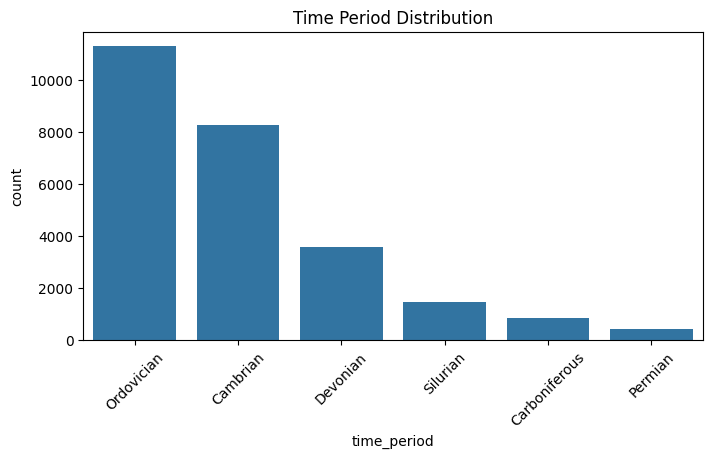

In [46]:
#عدد الاحافير في كل فترة
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="time_period", order=df["time_period"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Time Period Distribution")
plt.show()

The majority of trilobite fossils are found in the Ordovician and Cambrian periods, indicating that trilobites were most abundant during early geological eras.

In [47]:
#Which countries have the highest number of fossil findings?
df_eda["country"].value_counts().head(10)

,count
country,
US,8687
CA,3874
CN,3440
CZ,1393
NO,1318
AR,1274
SE,1191
UK,1030
RU,959


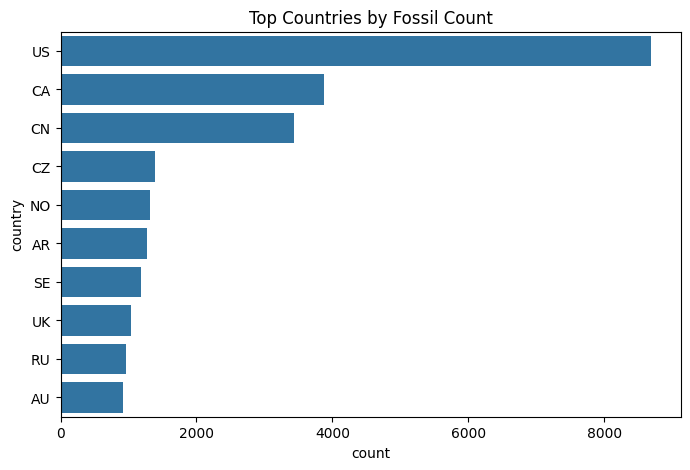

In [48]:
top_countries = df_eda["country"].value_counts().head(10).index

plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, y="country", order=top_countries)
plt.title("Top Countries by Fossil Count")
plt.show()

In [49]:
#What are the most common geological environments?
df_eda["environment"].value_counts().head(10)

,count
environment,
marine indet.,7247
carbonate indet.,5675
slope,2990
shallow subtidal indet.,2390
offshore,2004
open shallow subtidal,1530
"reef, buildup or bioherm",1351
deep subtidal indet.,878
deep subtidal shelf,758


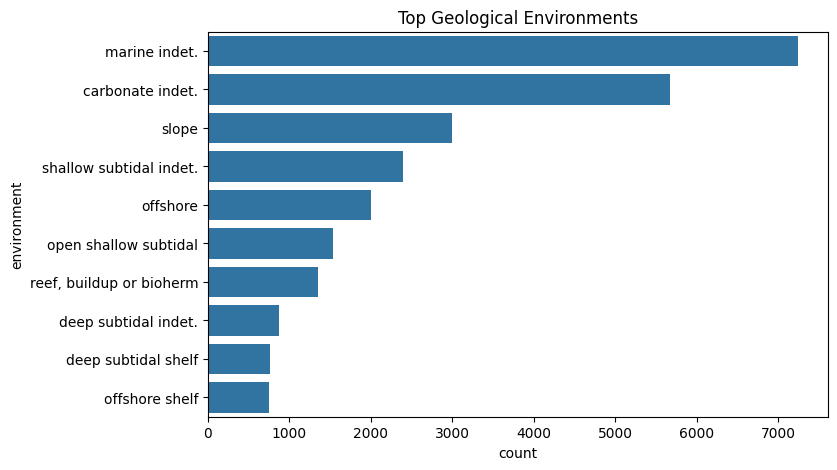

In [50]:
top_env = df_eda["environment"].value_counts().head(10).index

plt.figure(figsize=(8,5))
sns.countplot(data=df_eda, y="environment", order=top_env)
plt.title("Top Geological Environments")
plt.show()

             genus_num  max_age_mya  min_age_mya  longitude  latitude
genus_num     1.000000    -0.018036    -0.012466   0.155084 -0.020598
max_age_mya  -0.018036     1.000000     0.994298  -0.070465 -0.062128
min_age_mya  -0.012466     0.994298     1.000000  -0.051637 -0.060854
longitude     0.155084    -0.070465    -0.051637   1.000000 -0.162694
latitude     -0.020598    -0.062128    -0.060854  -0.162694  1.000000


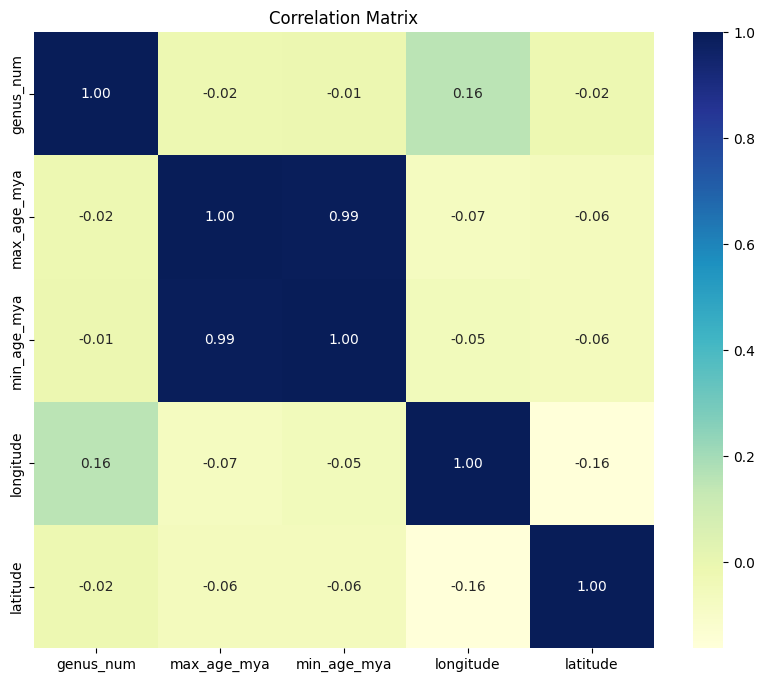

In [51]:
numeric_cols = ['genus_num', 'max_age_mya', 'min_age_mya', 'longitude', 'latitude']
corr_matrix = df_eda[numeric_cols].corr()

print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

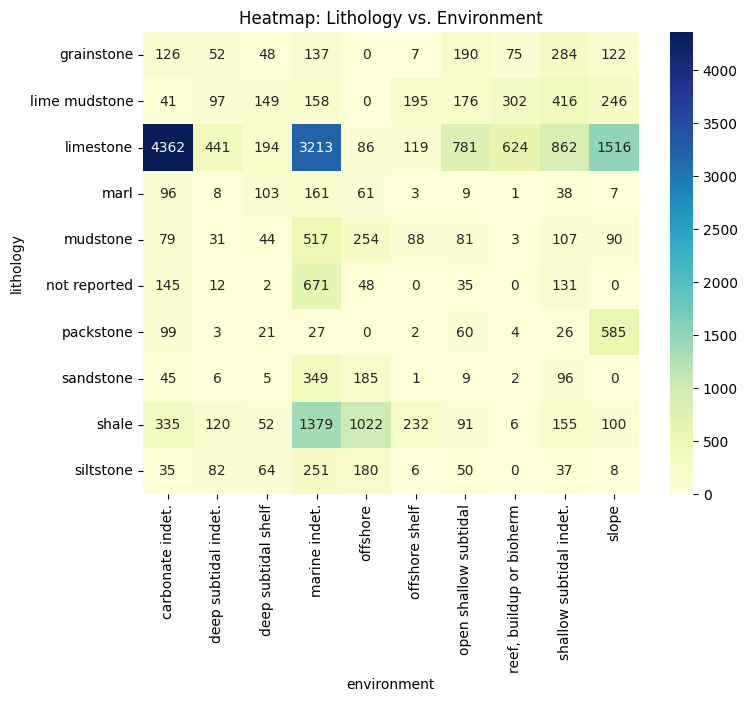

In [52]:
top_lith = df_eda['lithology'].value_counts().nlargest(10).index
top_env = df_eda['environment'].value_counts().nlargest(10).index

ct = pd.crosstab(df_eda[df_eda['lithology'].isin(top_lith)]['lithology'],
                 df_eda[df_eda['environment'].isin(top_env)]['environment'])

plt.figure(figsize=(8,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Lithology vs. Environment')
plt.show()

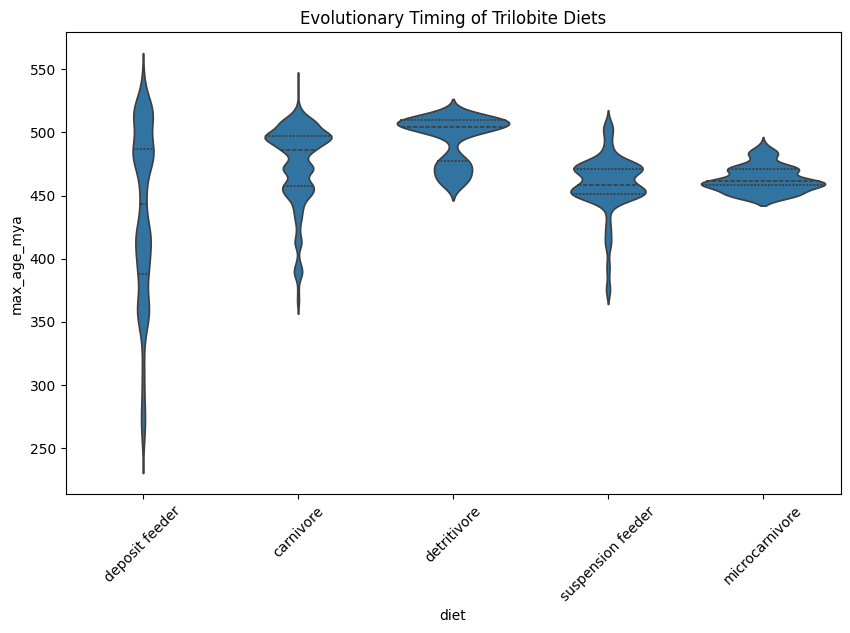

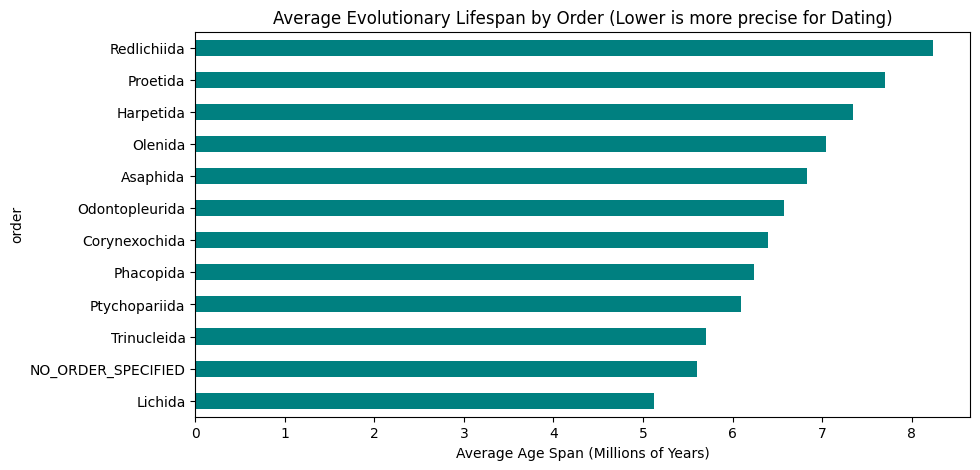

<Figure size 1000x400 with 0 Axes>

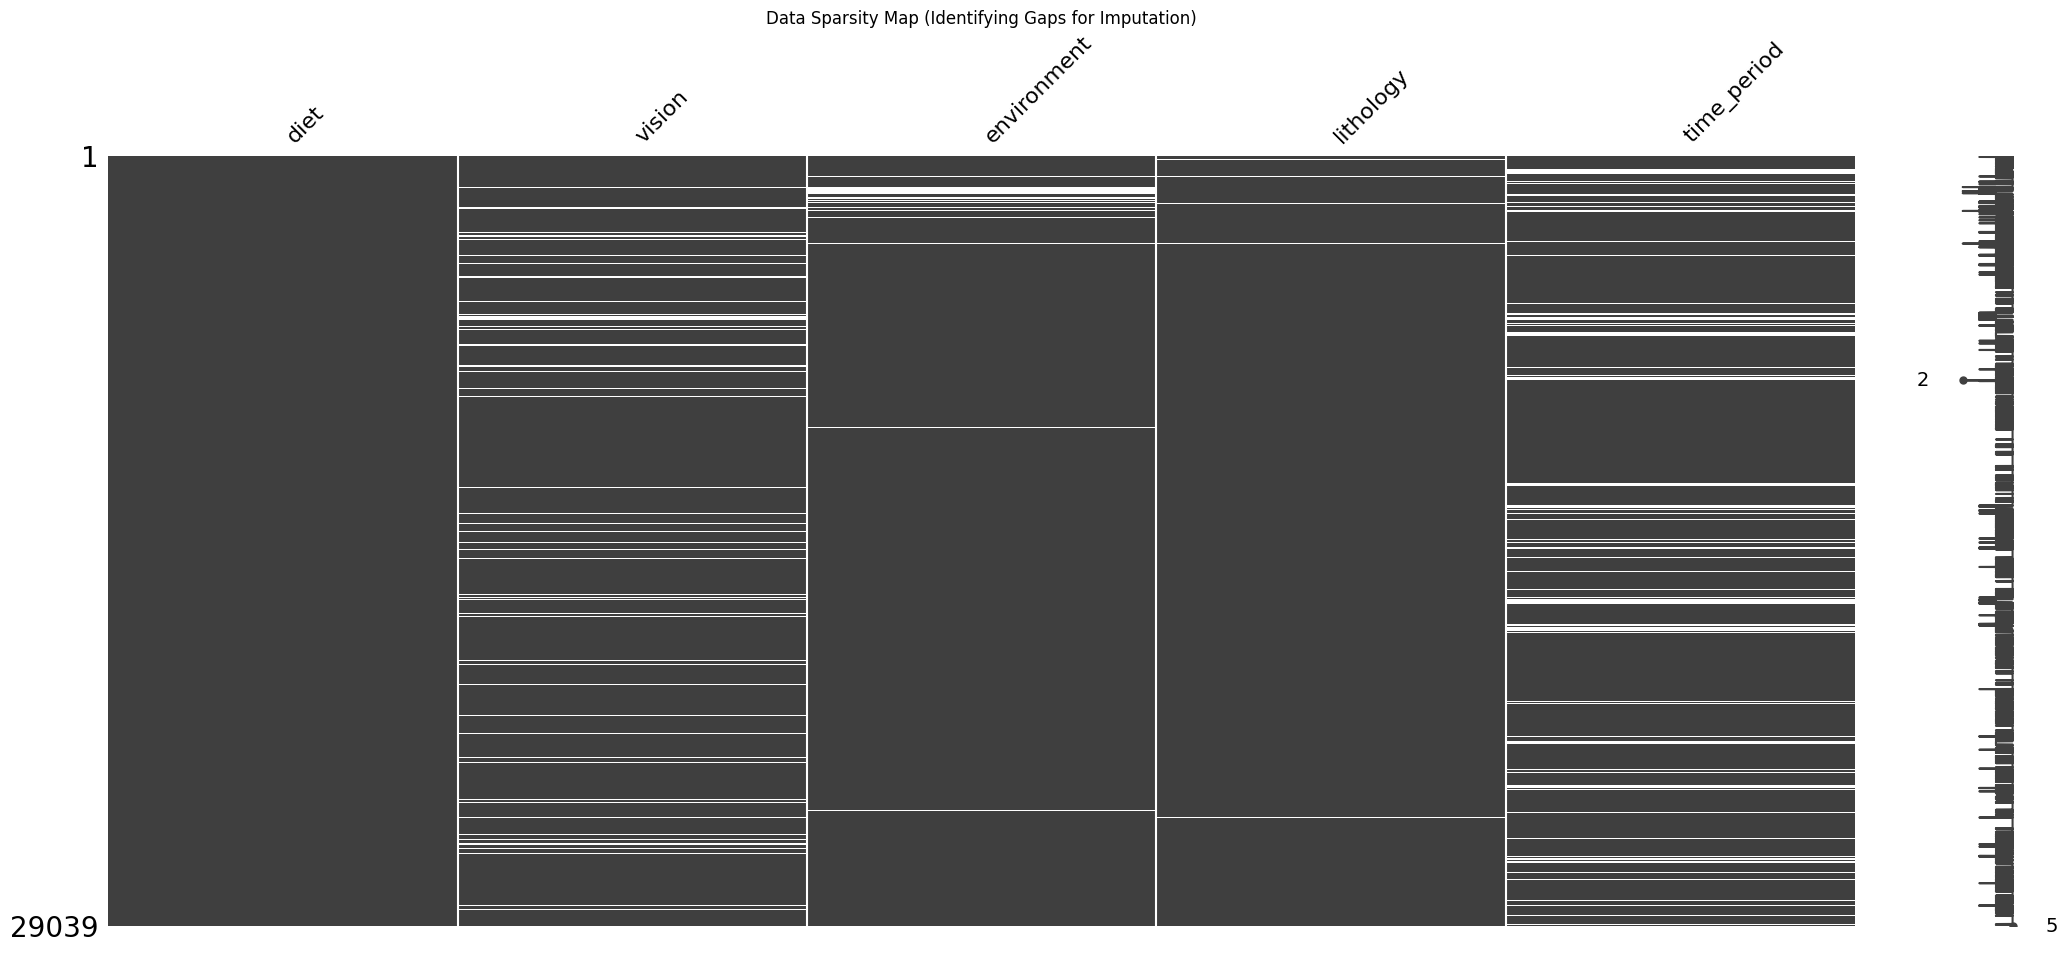

In [53]:
# 1. Biological Trait Evolution (Diet over Time)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_eda, x='diet', y='max_age_mya', inner="quart")
plt.title('Evolutionary Timing of Trilobite Diets')
plt.xticks(rotation=45)
plt.show()

# 2. Taxonomic Precision (Which Orders lived the longest?)
df_eda['age_span'] = df_eda['max_age_mya'] - df_eda['min_age_mya']
order_precision = df_eda.groupby('order')['age_span'].mean().sort_values()

plt.figure(figsize=(10, 5))
order_precision.plot(kind='barh', color='teal')
plt.title('Average Evolutionary Lifespan by Order (Lower is more precise for Dating)')
plt.xlabel('Average Age Span (Millions of Years)')
plt.show()

# 3. Missingness Heatmap
import missingno as msno
plt.figure(figsize=(10,4))
msno.matrix(df_eda[['diet', 'vision', 'environment', 'lithology', 'time_period']])
plt.title('Data Sparsity Map (Identifying Gaps for Imputation)')
plt.show()

Numeric Correlation with Age:
max_age_mya    1.000000
min_age_mya    0.994317
longitude     -0.058142
latitude      -0.060440
Name: max_age_mya, dtype: float64


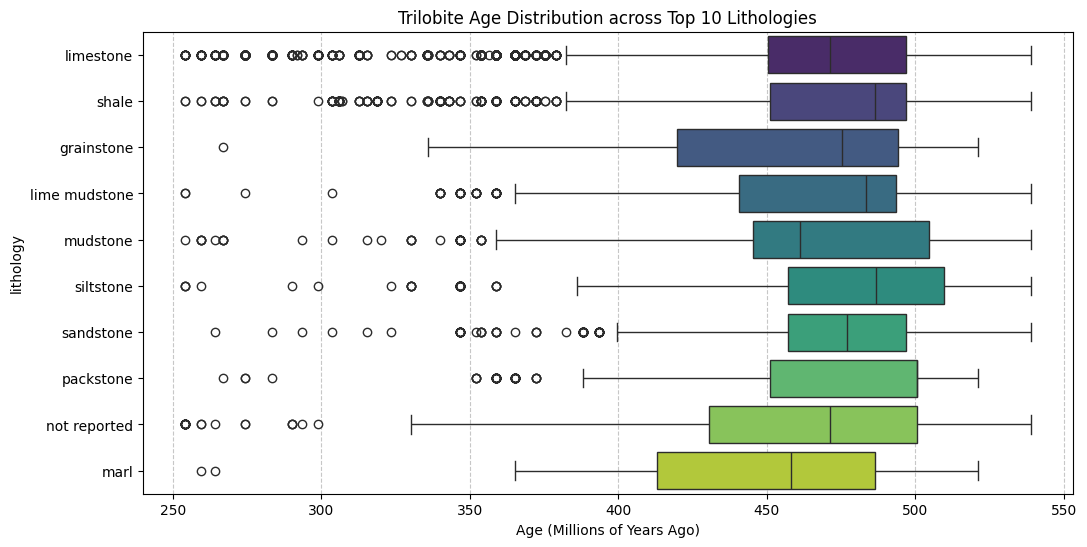

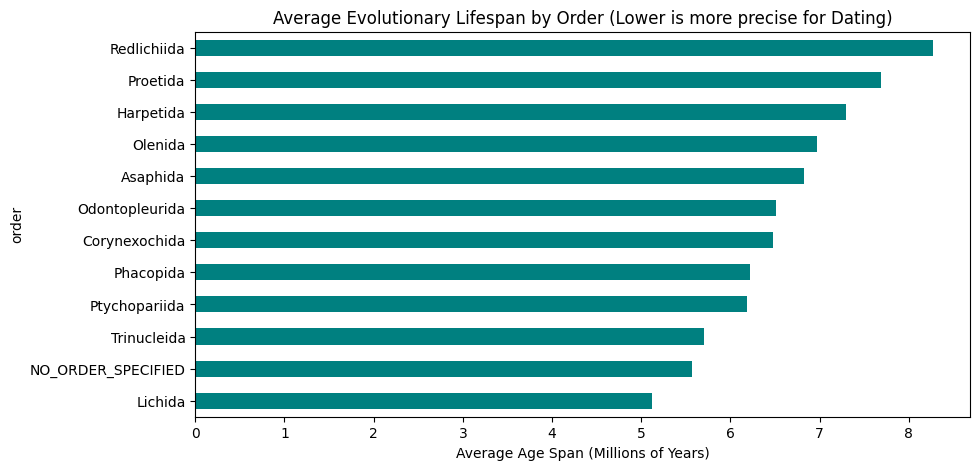

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clean Data
df_eda = df_eda.dropna(subset=['max_age_mya', 'lithology', 'environment', 'order', 'min_age_mya'])

# Check for Target Leakage
print("Numeric Correlation with Age:")
print(df_eda[['max_age_mya', 'min_age_mya', 'longitude', 'latitude']].corr()['max_age_mya'])

# Visualizing Age Distribution by Rock Type (Top 10)
top_lith = df_eda['lithology'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda[df_eda['lithology'].isin(top_lith)],
            x='max_age_mya', y='lithology', palette='viridis')
plt.title('Trilobite Age Distribution across Top 10 Lithologies')
plt.xlabel('Age (Millions of Years Ago)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Calculation for the Bar Chart
df_eda['age_span'] = df_eda['max_age_mya'] - df_eda['min_age_mya']
order_precision = df_eda.groupby('order')['age_span'].mean().sort_values()

# Plotting the Precision Chart
plt.figure(figsize=(10, 5))
order_precision.plot(kind='barh', color='teal')
plt.title('Average Evolutionary Lifespan by Order (Lower is more precise for Dating)')
plt.xlabel('Average Age Span (Millions of Years)')
plt.show()

# Machine Learning Part
In this section, we apply machine learning techniques to classify trilobite fossils into their geological time periods.

We will build and compare different models to evaluate their performance and understand the impact of various features.

## First Model: Time Period Classification

In [56]:
print("Original dataset shape:", df.shape)
print("Classification copy shape:", df_cls.shape)

Original dataset shape: (25855, 2869)
Classification copy shape: (29039, 30)


In [59]:
# Drop unnecessary and leakage-related columns
# These columns are removed because:
# - Some are high-cardinality and may create too many dummy columns
# - Some are duplicated numeric codes
# - Some are directly related to time and may cause data leakage

cols_to_drop = [
    "scientific_name",
    "species",
    "collection_name",
    "order_num",
    "family_num",
    "genus_num",
    "latlng_precision",
    "early_interval",
    "late_interval",
    "max_age_mya",
    "min_age_mya",
    "formation",
    "stratigraphy_scale"
]

df_cls = df_cls.drop(columns=cols_to_drop, errors="ignore")

print("Shape after dropping columns:", df_cls.shape)


Shape after dropping columns: (29039, 17)


In [61]:
for col in df_cls.columns:
    print(col)

order
family
genus
country
state
longitude
latitude
latlng_basis
lithology
environment
assembly_composition
preservation_mode
collection_type
life_habit
vision
diet
time_period


##   Model A (Using All Features)

###  Description:

Model A was trained using all available features in the dataset, including taxonomic information such as *genus, family, and order*, along with environmental, geographical, and biological attributes.

###  Models Used:
- **Baseline Model:** Decision Tree  
- **Advanced Model:** Random Forest  

###  Performance:
- Decision Tree Accuracy: **97.7%**  
- Random Forest Accuracy: **98.5%**  

###  Interpretation:
The high accuracy indicates that the model was able to learn strong patterns from the data. Taxonomic features (*genus, family, order*) played a major role in improving performance, as they are strongly associated with specific geological time periods.

###  Insight:
While the model performs extremely well, part of this performance comes from strong correlations between biological classification and time periods, meaning the model relies heavily on these features.


In [67]:
# Model A: Using All Features

# Remove rows with missing target first
df_cls = df_cls.dropna(subset=["time_period"]).copy()

# Fill missing values
# Numerical columns -> median
num_cols_A = df_cls.select_dtypes(include=["number"]).columns.tolist()

# Categorical columns -> "Unknown"
cat_cols_A = df_cls.select_dtypes(include=["object"]).columns.tolist()

for col in num_cols_A:
    df_cls[col] = df_cls[col].fillna(df_cls[col].median())

for col in cat_cols_A:
    df_cls[col] = df_cls[col].fillna("Unknown")

# Define X and y
X_A = df_cls.drop(columns=["time_period"])
y_A = df_cls["time_period"]

In [68]:
# Split
from sklearn.model_selection import train_test_split

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A,
    test_size=0.2,
    random_state=42,
    stratify=y_A
)

# Encoding
categorical_cols_A = X_train_A.select_dtypes(include=["object"]).columns.tolist()

X_train_A = pd.get_dummies(X_train_A, columns=categorical_cols_A, dtype=int)
X_test_A = pd.get_dummies(X_test_A, columns=categorical_cols_A, dtype=int)

X_train_A, X_test_A = X_train_A.align(X_test_A, join="left", axis=1, fill_value=0)


# Baseline Model: Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_A = DecisionTreeClassifier(random_state=42)
dt_A.fit(X_train_A, y_train_A)

y_pred_dt_A = dt_A.predict(X_test_A)
dt_acc_A = accuracy_score(y_test_A, y_pred_dt_A)

print("\nModel A - Decision Tree Accuracy:", dt_acc_A)
print(classification_report(y_test_A, y_pred_dt_A))


# Second Model: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_A = RandomForestClassifier(n_estimators=200, random_state=42)
rf_A.fit(X_train_A, y_train_A)

y_pred_rf_A = rf_A.predict(X_test_A)
rf_acc_A = accuracy_score(y_test_A, y_pred_rf_A)

print("\nModel A - Random Forest Accuracy:", rf_acc_A)
print(classification_report(y_test_A, y_pred_rf_A))


Model A - Decision Tree Accuracy: 0.9771812080536912
               precision    recall  f1-score   support

     Cambrian       0.99      0.99      0.99      1663
Carboniferous       0.92      0.97      0.94       172
     Devonian       0.97      0.96      0.97       730
   Ordovician       0.98      0.98      0.98      2275
      Permian       0.99      0.90      0.94        81
     Silurian       0.92      0.92      0.92       294

     accuracy                           0.98      5215
    macro avg       0.96      0.95      0.96      5215
 weighted avg       0.98      0.98      0.98      5215


Model A - Random Forest Accuracy: 0.9850431447746884
               precision    recall  f1-score   support

     Cambrian       1.00      0.99      0.99      1663
Carboniferous       0.93      0.97      0.95       172
     Devonian       0.97      0.98      0.98       730
   Ordovician       0.99      0.99      0.99      2275
      Permian       1.00      0.90      0.95        81
     Sil

##  Model B (Without Taxonomy Features)

###  Description:

Model B was trained after removing taxonomic features (*genus, family, and order*) to test whether the model can predict geological time periods using only environmental, geographical, and biological characteristics.

###  Models Used:
- **Baseline Model:** Decision Tree  
- **Advanced Model:** Random Forest  

###  Performance:
- Decision Tree Accuracy: **96.5%**  
- Random Forest Accuracy: **97.4%**  

###  Interpretation:
Although the accuracy decreased compared to Model A, the model still achieved strong performance. This shows that environmental and geological features alone contain meaningful information for predicting time periods.

###  Insight:
The drop in accuracy confirms that taxonomic features significantly improve model performance, but the model can still generalize reasonably well without them.

In [69]:
# Model B: Without Taxonomy Features

df_B = df_cls.drop(columns=["genus", "family", "order"], errors="ignore").copy()

# Remove rows with missing target
df_B = df_B.dropna(subset=["time_period"]).copy()

# Fill missing values
num_cols_B = df_B.select_dtypes(include=["number"]).columns.tolist()
cat_cols_B = df_B.select_dtypes(include=["object"]).columns.tolist()

for col in num_cols_B:
    df_B[col] = df_B[col].fillna(df_B[col].median())

for col in cat_cols_B:
    df_B[col] = df_B[col].fillna("Unknown")

# Define X and y
X_B = df_B.drop(columns=["time_period"])
y_B = df_B["time_period"]

In [70]:
# Split
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B,
    test_size=0.2,
    random_state=42,
    stratify=y_B
)

# Encoding
categorical_cols_B = X_train_B.select_dtypes(include=["object"]).columns.tolist()

X_train_B = pd.get_dummies(X_train_B, columns=categorical_cols_B, dtype=int)
X_test_B = pd.get_dummies(X_test_B, columns=categorical_cols_B, dtype=int)

X_train_B, X_test_B = X_train_B.align(X_test_B, join="left", axis=1, fill_value=0)


# Baseline Model: Decision Tree
dt_B = DecisionTreeClassifier(random_state=42)
dt_B.fit(X_train_B, y_train_B)

y_pred_dt_B = dt_B.predict(X_test_B)
dt_acc_B = accuracy_score(y_test_B, y_pred_dt_B)

print("\nModel B - Decision Tree Accuracy:", dt_acc_B)
print(classification_report(y_test_B, y_pred_dt_B))


# Second Model: Random Forest
rf_B = RandomForestClassifier(n_estimators=200, random_state=42)
rf_B.fit(X_train_B, y_train_B)

y_pred_rf_B = rf_B.predict(X_test_B)
rf_acc_B = accuracy_score(y_test_B, y_pred_rf_B)

print("\nModel B - Random Forest Accuracy:", rf_acc_B)
print(classification_report(y_test_B, y_pred_rf_B))


Model B - Decision Tree Accuracy: 0.9649089165867689
               precision    recall  f1-score   support

     Cambrian       0.98      0.98      0.98      1663
Carboniferous       0.87      0.91      0.89       172
     Devonian       0.96      0.93      0.95       730
   Ordovician       0.98      0.98      0.98      2275
      Permian       0.87      0.85      0.86        81
     Silurian       0.87      0.94      0.90       294

     accuracy                           0.96      5215
    macro avg       0.92      0.93      0.93      5215
 weighted avg       0.97      0.96      0.97      5215


Model B - Random Forest Accuracy: 0.9748801534036433
               precision    recall  f1-score   support

     Cambrian       0.98      0.98      0.98      1663
Carboniferous       0.88      0.94      0.91       172
     Devonian       0.97      0.95      0.96       730
   Ordovician       0.98      0.99      0.98      2275
      Permian       1.00      0.90      0.95        81
     Sil

In [71]:
comparison = pd.DataFrame({
    "Model": [
        "Model A - Decision Tree",
        "Model A - Random Forest",
        "Model B - Decision Tree",
        "Model B - Random Forest"
    ],
    "Accuracy": [
        dt_acc_A,
        rf_acc_A,
        dt_acc_B,
        rf_acc_B
    ]
})

print("\nFinal Comparison:\n")
print(comparison)


Final Comparison:

                     Model  Accuracy
0  Model A - Decision Tree  0.977181
1  Model A - Random Forest  0.985043
2  Model B - Decision Tree  0.964909
3  Model B - Random Forest  0.974880


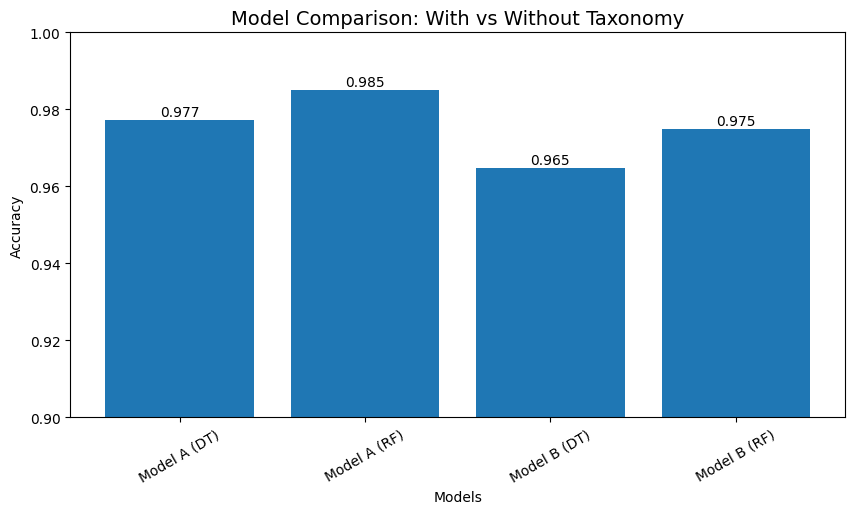

In [74]:
models = [
    "Model A (DT)", "Model A (RF)",
    "Model B (DT)", "Model B (RF)"
]

accuracies = [
    dt_acc_A, rf_acc_A,
    "DT (No Tax)", "RF (No Tax)"
]

accuracies = [
    dt_acc_A, rf_acc_A,
    dt_acc_B, rf_acc_B
]

plt.figure(figsize=(10,5))

plt.bar(models, accuracies)

plt.title("Model Comparison: With vs Without Taxonomy", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0.9, 1.0)
plt.xticks(rotation=30)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.3f}", ha='center')

plt.show()



##  Comparison Insight

###  Description:

Comparing Model A and Model B reveals the importance of taxonomic features:

- Including taxonomy → **higher accuracy (~98%)**  
- Removing taxonomy → **lower but still strong accuracy (~97%)**  

###  Key Conclusion:

> Taxonomic features such as genus, family, and order have a strong influence on predicting geological time periods. However, environmental and geographical features also provide valuable predictive power.

---

##  Final Insight

> The comparison between Model A and Model B demonstrates that taxonomic features significantly enhance model performance. However, even without these features, the model maintains strong predictive ability, indicating that environmental and geological factors also play a critical role in determining geological time periods.

# Second Model: Predicting distribution by country

In [ ]:
df["country"].unique()

array(['US', 'CA', 'IE', 'UK', 'AU', 'RU', 'KG', 'NO', 'SE', 'CN', 'CZ',
       'DE', 'FR', 'MA', 'KR', 'ES', 'GL', 'AR', 'CO', 'MX', 'KZ', 'LV',
       'EE', 'UA', 'PL', 'AT', 'PT', 'PY', 'IT', 'ZA', 'DZ', 'TR', 'BE',
       'BR', 'EH', 'NZ', 'VE', 'GT', 'TN', 'PK', 'AQ', 'KP', 'IR', 'SI',
       'AF', 'MY', 'TH', 'DK', 'SA', 'MN', 'JP', 'VN', 'AZ', 'OM', 'SJ',
       'AM', 'ID', 'FI', 'TJ', 'UZ', 'MM', 'NL', 'LT', 'BY', 'BA', 'LU',
       'LA'], dtype=object)

In [ ]:
country_to_continent = {
    # North America
    "US": "North America", "CA": "North America", "MX": "North America", "GT": "North America",

    # South America
    "AR": "South America", "BR": "South America", "CO": "South America", "VE": "South America", "PY": "South America",

    # Europe
    "UK": "Europe", "IE": "Europe", "FR": "Europe", "DE": "Europe", "ES": "Europe",
    "IT": "Europe", "PL": "Europe", "CZ": "Europe", "AT": "Europe", "BE": "Europe",
    "NL": "Europe", "LU": "Europe", "SE": "Europe", "NO": "Europe", "FI": "Europe",
    "DK": "Europe", "PT": "Europe", "EE": "Europe", "LV": "Europe", "LT": "Europe",
    "UA": "Europe", "BY": "Europe", "SI": "Europe", "BA": "Europe",

    # Asia
    "CN": "Asia", "IN": "Asia", "JP": "Asia", "KR": "Asia", "KP": "Asia",
    "TH": "Asia", "VN": "Asia", "MY": "Asia", "ID": "Asia",
    "IR": "Asia", "PK": "Asia", "AF": "Asia",
    "KZ": "Asia", "UZ": "Asia", "TJ": "Asia", "KG": "Asia",
    "AZ": "Asia", "AM": "Asia", "MN": "Asia", "LA": "Asia", "MM": "Asia", "BT": "Asia",

    # Africa
    "MA": "Africa", "DZ": "Africa", "TN": "Africa", "ZA": "Africa", "EH": "Africa",

    # Oceania
    "AU": "Oceania", "NZ": "Oceania",

    # Middle East
    "SA": "Middle East", "JO": "Middle East", "OM": "Middle East",

    # Polar / Special
    "AQ": "Antarctica", "GL": "North America", "SJ": "Europe"
}

In [ ]:
df["continent"] = df["country"].map(country_to_continent)

In [ ]:
df["continent"] = df["continent"].fillna("Other")

In [ ]:
X = df.drop([
    "country",
    "continent",
    "time_period",
    "avg_age",
    "latitude",
    "longitude"
], axis=1)

y = df["continent"]

In [ ]:
X = pd.get_dummies(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9569498069498069


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

       Africa       0.98      0.88      0.93       172
   Antarctica       1.00      0.60      0.75         5
         Asia       0.98      0.95      0.96       775
       Europe       0.93      0.97      0.95      1353
  Middle East       0.67      0.33      0.44         6
North America       0.97      0.98      0.97      2273
      Oceania       0.94      0.86      0.90       171
        Other       0.94      0.90      0.92       196
South America       0.96      0.93      0.95       229

     accuracy                           0.96      5180
    macro avg       0.93      0.82      0.86      5180
 weighted avg       0.96      0.96      0.96      5180



Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred_lr = model_lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.876061776061776
               precision    recall  f1-score   support

       Africa       0.49      0.91      0.64       172
   Antarctica       0.71      1.00      0.83         5
         Asia       0.92      0.88      0.90       775
       Europe       0.89      0.80      0.84      1353
  Middle East       0.11      0.50      0.18         6
North America       0.97      0.91      0.94      2273
      Oceania       0.74      0.92      0.82       171
        Other       0.69      0.92      0.79       196
South America       0.77      0.92      0.84       229

     accuracy                           0.88      5180
    macro avg       0.70      0.86      0.75      5180
 weighted avg       0.90      0.88      0.88      5180



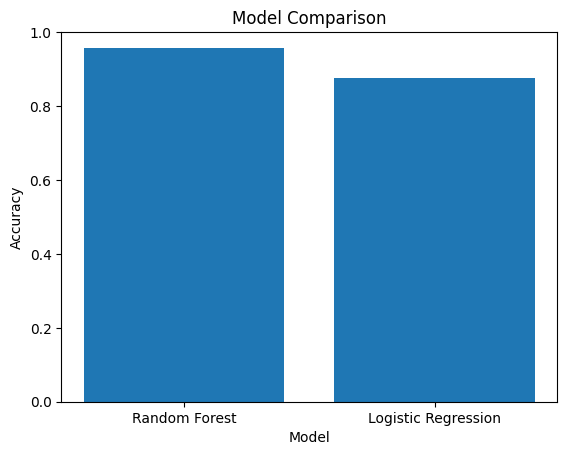

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

models = ["Random Forest", "Logistic Regression"]
accuracies = [rf_accuracy, lr_accuracy]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)

plt.show()

Model Performance Comparison

The Random Forest model achieved superior performance compared to Logistic Regression, with higher overall accuracy and more consistent results across most classes.

While applying class weighting improved the ability of both models to detect minority classes, Random Forest maintained a strong balance between accuracy and class-wise performance. In contrast, Logistic Regression showed a noticeable drop in overall accuracy despite improved recall for underrepresented classes.

This indicates that Random Forest is better suited for handling complex patterns and class imbalance in this dataset.

# Third Model: Age prediction

### PREPARATION FOR AGE PREDICTION

In [ ]:
# =========================================
# FINAL PREPARATION FOR AGE PREDICTION
# work on a copy only
# =========================================

import pandas as pd
import numpy as np

# make a separate copy for age prediction
predict_age_df = df.copy()

# 1) define target
y = predict_age_df["avg_age"].copy()

# 2) remove target and leakage column from features
X = predict_age_df.drop(columns=["avg_age", "time_period"], errors="ignore").copy()

# remove all one-hot encoded family/order columns for regression
cols_to_drop = [col for col in X.columns if col.startswith("family_") or col.startswith("order_")]

X = X.drop(columns=cols_to_drop, errors="ignore").copy()

print("Dropped columns count:", len(cols_to_drop))
print("Example dropped columns:", cols_to_drop[:10])
print("New X shape:", X.shape)


print("Working dataframe name: predict_age_df")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Data is ready for age prediction modeling.")

Dropped columns count: 178
Example dropped columns: ['order_Asaphida', 'order_Corynexochida', 'order_Harpetida', 'order_Lichida', 'order_NO_ORDER_SPECIFIED', 'order_Odontopleurida', 'order_Olenida', 'order_Phacopida', 'order_Proetida', 'order_Ptychopariida']
New X shape: (25855, 2689)
Working dataframe name: predict_age_df
X shape: (25855, 2689)
y shape: (25855,)
Data is ready for age prediction modeling.


#### FEATURE SELECTION

In [ ]:
# =========================================
# FEATURE SELECTION
# =========================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    mutual_info_regression,
    VarianceThreshold,
    RFE
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# -----------------------------------------
# 1) Split FIRST
# -----------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

k = 50

# -----------------------------------------
# 2) Remove low variance features
# -----------------------------------------
var_selector = VarianceThreshold(threshold=0.01)

X_train_var = var_selector.fit_transform(X_train)
X_test_var = var_selector.transform(X_test)

var_features = X_train.columns[var_selector.get_support()]

X_train_var = pd.DataFrame(X_train_var, columns=var_features, index=X_train.index)
X_test_var = pd.DataFrame(X_test_var, columns=var_features, index=X_test.index)

print("Shape after VarianceThreshold:")
print("X_train_var:", X_train_var.shape)
print("X_test_var :", X_test_var.shape)

# -----------------------------------------
# 3) Method 1: SelectKBest
# -----------------------------------------
kbest = SelectKBest(score_func=f_regression, k=min(k, X_train_var.shape[1]))
kbest.fit(X_train_var, y_train)

kbest_scores = pd.Series(kbest.scores_, index=X_train_var.columns).fillna(0)
kbest_top = kbest_scores.sort_values(ascending=False).head(k)
kbest_features = kbest_top.index.tolist()

print("\nTop features from SelectKBest:")
print(kbest_features[:20])

# -----------------------------------------
# 4) Method 2: Mutual Information
# -----------------------------------------
mi_scores = mutual_info_regression(X_train_var, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_train_var.columns).fillna(0)
mi_top = mi_scores.sort_values(ascending=False).head(k)
mi_features = mi_top.index.tolist()

print("\nTop features from Mutual Information:")
print(mi_features[:20])

# -----------------------------------------
# 5) Method 3: Random Forest Importance
# -----------------------------------------
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_var, y_train)

rf_scores = pd.Series(rf.feature_importances_, index=X_train_var.columns).fillna(0)
rf_top = rf_scores.sort_values(ascending=False).head(k)
rf_features = rf_top.index.tolist()

print("\nTop features from Random Forest Importance:")
print(rf_features[:20])

# -----------------------------------------
# 6) Method 4: RFE
# -----------------------------------------
rfe = RFE(estimator=LinearRegression(), n_features_to_select=min(k, X_train_var.shape[1]))
rfe.fit(X_train_var, y_train)

rfe_features = X_train_var.columns[rfe.support_].tolist()

# RFE ranking: 1 means selected, larger = less important
rfe_ranking = pd.Series(rfe.ranking_, index=X_train_var.columns)

print("\nTop features from RFE:")
print(rfe_features[:20])

# -----------------------------------------
# 7) Build a detailed ranking table per method
# -----------------------------------------
all_cols = X_train_var.columns

feature_summary = pd.DataFrame(index=all_cols)

# membership flags
feature_summary["Selected_KBest"] = feature_summary.index.isin(kbest_features).astype(int)
feature_summary["Selected_MI"] = feature_summary.index.isin(mi_features).astype(int)
feature_summary["Selected_RF"] = feature_summary.index.isin(rf_features).astype(int)
feature_summary["Selected_RFE"] = feature_summary.index.isin(rfe_features).astype(int)

# raw scores
feature_summary["KBest_Score"] = kbest_scores
feature_summary["MI_Score"] = mi_scores
feature_summary["RF_Importance"] = rf_scores
feature_summary["RFE_Rank"] = rfe_ranking

# convert top-k lists to rank positions
def rank_map(feature_list):
    return {feat: i + 1 for i, feat in enumerate(feature_list)}

kbest_rank_map = rank_map(kbest_features)
mi_rank_map = rank_map(mi_features)
rf_rank_map = rank_map(rf_features)
rfe_rank_map = rank_map(rfe_features)

feature_summary["KBest_Rank"] = feature_summary.index.map(kbest_rank_map)
feature_summary["MI_Rank"] = feature_summary.index.map(mi_rank_map)
feature_summary["RF_Rank"] = feature_summary.index.map(rf_rank_map)
feature_summary["RFE_Selected_Rank"] = feature_summary.index.map(rfe_rank_map)

# frequency: how many methods selected this feature
feature_summary["Frequency"] = (
    feature_summary["Selected_KBest"] +
    feature_summary["Selected_MI"] +
    feature_summary["Selected_RF"] +
    feature_summary["Selected_RFE"]
)

# average rank across methods that selected the feature
rank_cols = ["KBest_Rank", "MI_Rank", "RF_Rank", "RFE_Selected_Rank"]
feature_summary["Average_Rank"] = feature_summary[rank_cols].mean(axis=1, skipna=True)

# final selected features: selected by at least 2 methods
selected_features = feature_summary[feature_summary["Frequency"] >= 2].index.tolist()

# sort professionally
feature_importance_table = (
    feature_summary
    .sort_values(by=["Frequency", "Average_Rank"], ascending=[False, True])
    .reset_index()
    .rename(columns={"index": "Encoded_Feature"})
)

print("\nFinal selected features count:", len(selected_features))
print("Most frequently selected encoded features:")
print(feature_importance_table[["Encoded_Feature", "Frequency", "Average_Rank"]].head(20))

# -----------------------------------------
# 8) Final selected data
# -----------------------------------------
X_train_selected = X_train_var[selected_features].copy()
X_test_selected = X_test_var[selected_features].copy()

print("\nX_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)
print("Feature selection completed successfully.")

# -----------------------------------------
# 9) Table 1: Encoded feature importance table
# -----------------------------------------
encoded_feature_table = feature_importance_table.copy()

print("\nTable 1: Encoded feature importance")
print(encoded_feature_table.head(20))

# -----------------------------------------
# 10) Table 2: Original feature importance before encoding
# -----------------------------------------
# Group encoded columns back to original feature names

original_feature_names = [
    "country",
    "longitude",
    "latitude",
    "order",
    "early_interval",
    "stratigraphy_scale",
    "lithology",
    "environment",
    "assembly_composition",
    "preservation_mode",
    "collection_type",
    "life_habit",
    "vision",
    "diet"
]

def map_to_original_feature(col_name):
    if col_name in ["longitude", "latitude"]:
        return col_name
    for base in original_feature_names:
        if col_name == base or col_name.startswith(base + "_"):
            return base
    return col_name

encoded_feature_table["Original_Feature"] = encoded_feature_table["Encoded_Feature"].apply(map_to_original_feature)

original_feature_table = (
    encoded_feature_table
    .groupby("Original_Feature", as_index=False)
    .agg({
        "Frequency": "sum",
        "Average_Rank": "mean"
    })
    .sort_values(by=["Frequency", "Average_Rank"], ascending=[False, True])
    .reset_index(drop=True)
)

print("\nTable 2: Original feature importance before encoding")
print(original_feature_table)



Shape after VarianceThreshold:
X_train_var: (20684, 100)
X_test_var : (5171, 100)

Top features from SelectKBest:
['diet_deposit feeder', 'diet_carnivore', 'country_DE', 'preservation_mode_cast,mold/impression', 'stratigraphy_scale_bed', 'early_interval_Late Famennian', 'early_interval_Givetian', 'early_interval_Eifelian', 'country_CN', 'environment_slope', 'early_interval_Delamaran', 'country_CZ', 'life_habit_low-level epifaunal', 'early_interval_Pragian', 'early_interval_Guzhangian', 'early_interval_Dyeran', 'life_habit_nektobenthic', 'assembly_composition_Unknown', 'stratigraphy_scale_group of beds', 'early_interval_Taijangian']

Top features from Mutual Information:
['longitude', 'latitude', 'country_US', 'diet_deposit feeder', 'country_CN', 'stratigraphy_scale_bed', 'diet_carnivore', 'collection_type_taxonomic', 'collection_type_biostratigraphic', 'assembly_composition_macrofossils', 'preservation_mode_body', 'assembly_composition_macrofossils,mesofossils', 'environment_slope', 'p

In [ ]:
# =========================================
# DISPLAY THE 63 SELECTED FEATURES + THEIR IMPORTANCE
# =========================================

selected_features_table = feature_importance_table[
    feature_importance_table["Encoded_Feature"].isin(selected_features)
][["Encoded_Feature", "Frequency", "Average_Rank"]].copy()

selected_features_table = selected_features_table.sort_values(
    by=["Frequency", "Average_Rank"],
    ascending=[False, True]
).reset_index(drop=True)



In [ ]:
print("Selected 63 Features with Importance:\n")
print(selected_features_table.to_string())

Selected 63 Features with Importance:

                                               Encoded_Feature  Frequency  Average_Rank
0                                          diet_deposit feeder          4     11.000000
1                                     early_interval_Delamaran          4     13.500000
2                       preservation_mode_cast,mold/impression          4     13.750000
3                                      early_interval_Givetian          4     15.250000
4                                       early_interval_Pragian          4     15.750000
5                                      early_interval_Eifelian          4     16.250000
6                                                   country_CN          4     16.750000
7                                    early_interval_Guzhangian          4     18.000000
8                                 assembly_composition_Unknown          4     18.500000
9                                        early_interval_Dyeran          4     20.

## BASELINE MODEL - LINEAR REGRESSION


In [ ]:
# =========================================
# BASELINE MODEL - LINEAR REGRESSION
# =========================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize the baseline model
baseline_model = LinearRegression()

# Train the model on the selected features
baseline_model.fit(X_train_selected, y_train)

# Generate predictions on the test set
y_pred_baseline = baseline_model.predict(X_test_selected)

# Evaluate model performance
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

# Store results in a DataFrame for clear presentation
baseline_results = pd.DataFrame({
    "Model": ["Baseline - Linear Regression"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2]
})

# Display results
print(baseline_results)

                          Model        MAE       RMSE        R2
0  Baseline - Linear Regression  21.122419  31.791967  0.575616


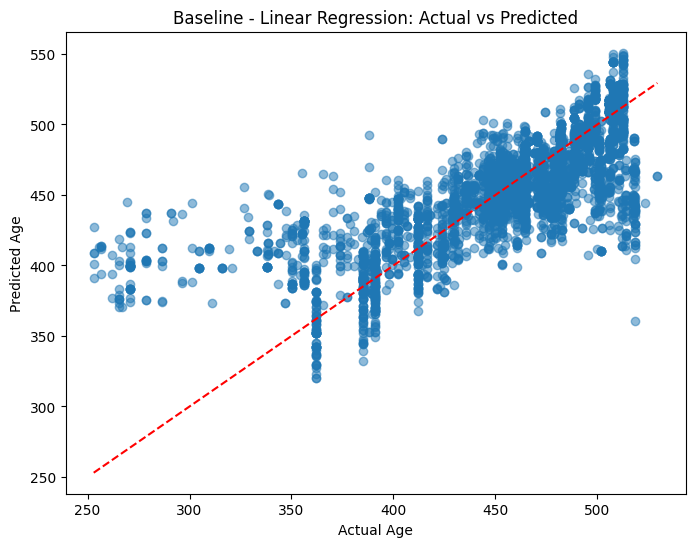

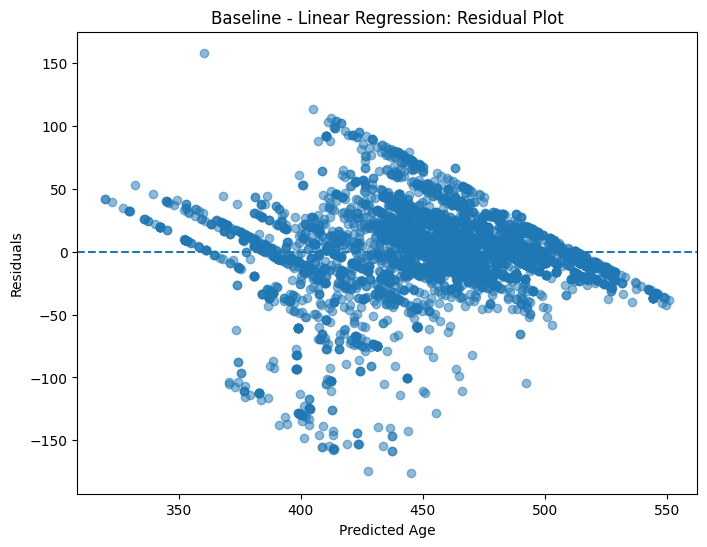

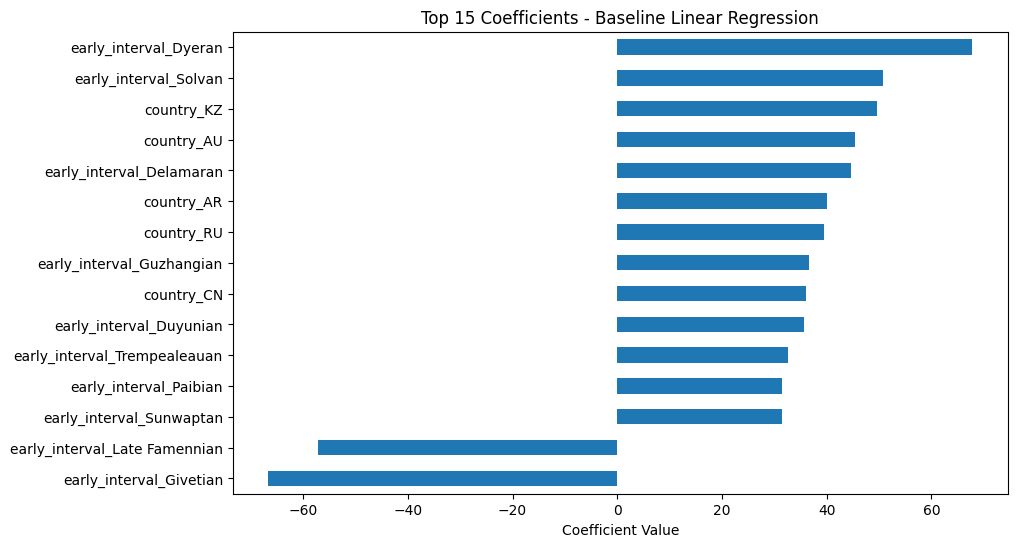

In [ ]:
# =========================================
# BASELINE VISUALIZATION
# =========================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1) Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_baseline, alpha=0.5)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Baseline - Linear Regression: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# 2) Residual Plot
residuals_baseline = y_test - y_pred_baseline

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_baseline, residuals_baseline, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("Baseline - Linear Regression: Residual Plot")
plt.show()

# 3) Coefficients Importance
baseline_coefficients = pd.Series(
    baseline_model.coef_,
    index=X_train_selected.columns
).sort_values(key=np.abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
baseline_coefficients.sort_values().plot(kind="barh")
plt.xlabel("Coefficient Value")
plt.title("Top 15 Coefficients - Baseline Linear Regression")
plt.show()

# Random Forest Regressor

In [ ]:
# =========================================
# RANDOM FOREST REGRESSOR
# =========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_selected, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_selected)

# Evaluate
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R2  :", round(rf_r2, 4))

Random Forest
MAE : 2.7818
RMSE: 11.3348
R2  : 0.9461


In [ ]:
# =========================================
# RANDOM FOREST COMPARISON TABLE
# =========================================

rf_results = pd.DataFrame({
    "Model": [
        "Baseline - Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2
    ]
})

print(rf_results)

                          Model        MAE       RMSE        R2
0  Baseline - Linear Regression  21.122419  31.791967  0.575616
1                 Random Forest   2.781772  11.334763  0.946055


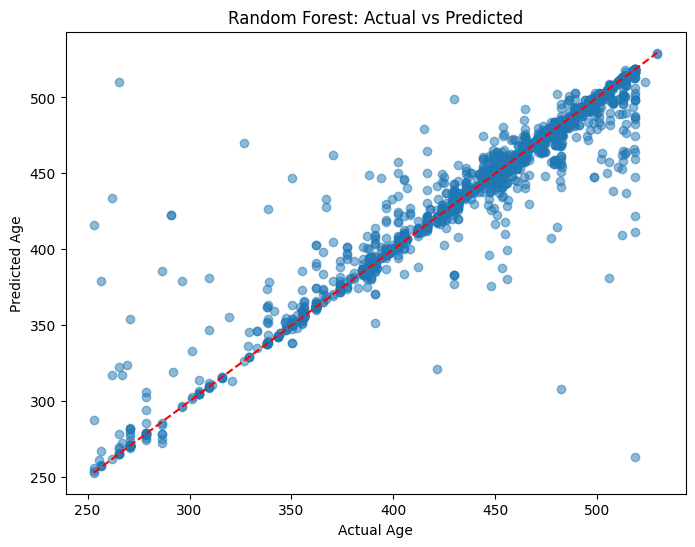

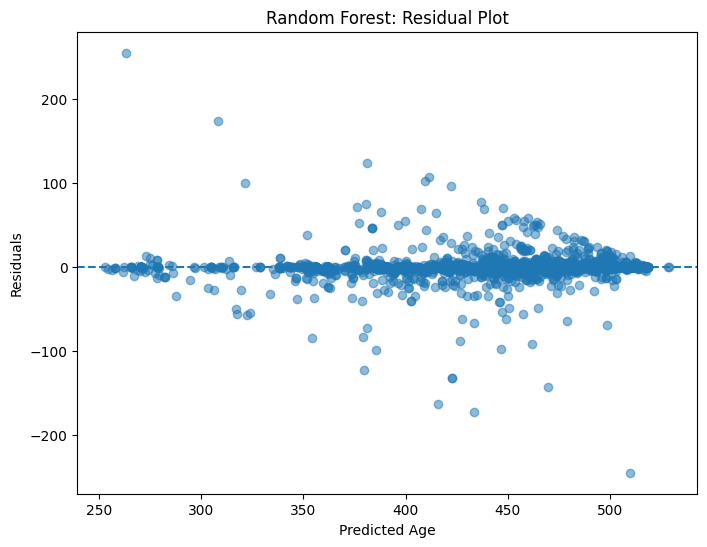

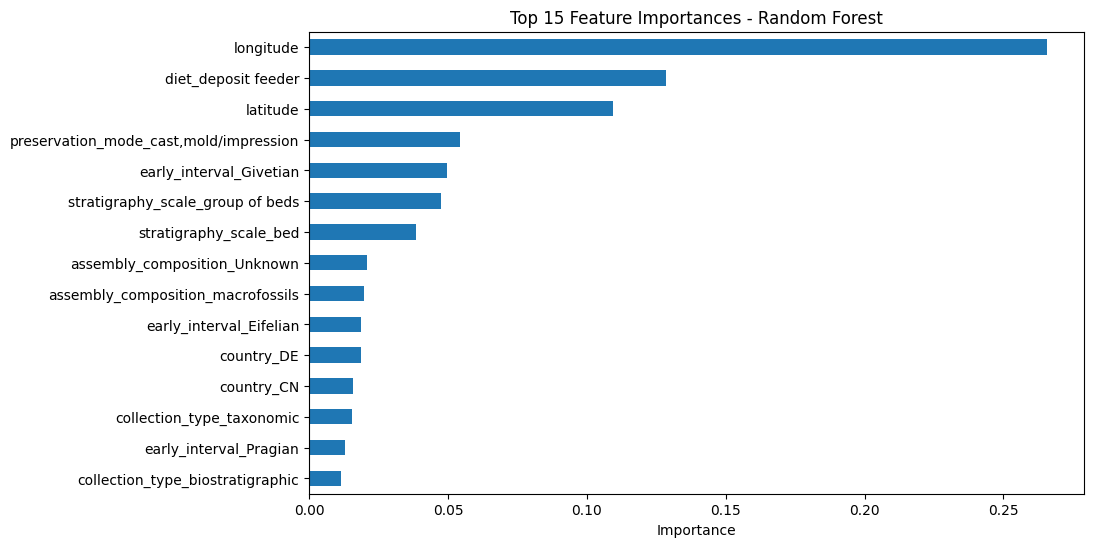

In [ ]:
# =========================================
# RANDOM FOREST VISUALIZATION
# =========================================

import matplotlib.pyplot as plt

# 1) Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# 2) Residuals plot
residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")
plt.show()

# 3) Feature importance
feature_importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train_selected.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feature_importance_rf.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()

# XGBoost

In [ ]:
# =========================================
# XGBOOST REGRESSOR
# =========================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train_selected, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test_selected)

# Evaluate
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE :", round(xgb_mae, 4))
print("RMSE:", round(xgb_rmse, 4))
print("R2  :", round(xgb_r2, 4))

XGBoost
MAE : 6.2181
RMSE: 12.8124
R2  : 0.9311


In [ ]:
# =========================================
# COMPARISON TABLE
# =========================================

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Baseline - Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2,
        xgb_r2
    ]
})

print(comparison_df.sort_values(by="R2", ascending=False))

                          Model        MAE       RMSE        R2
1                 Random Forest   2.781772  11.334763  0.946055
2                       XGBoost   6.218125  12.812375  0.931074
0  Baseline - Linear Regression  21.122419  31.791967  0.575616


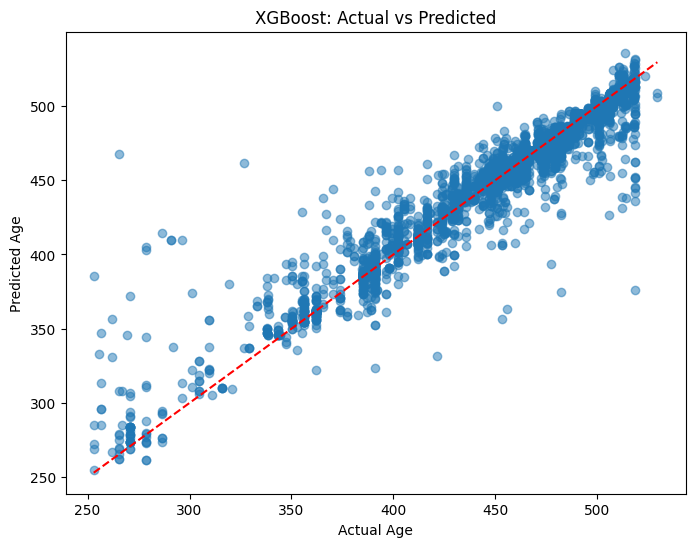

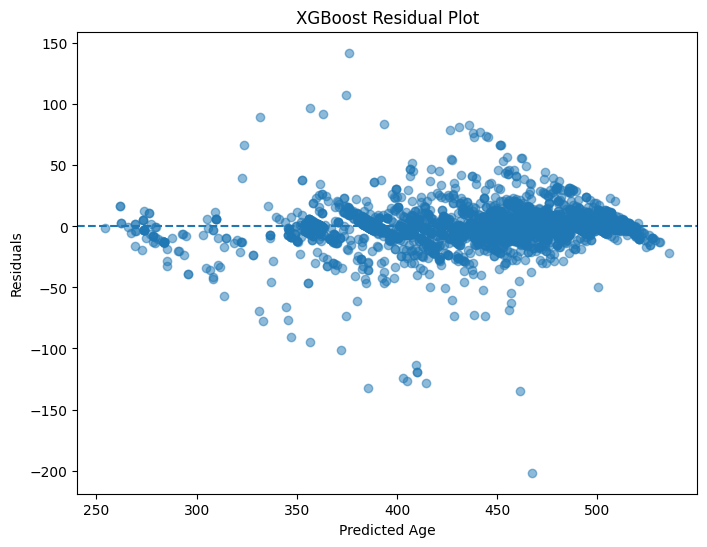

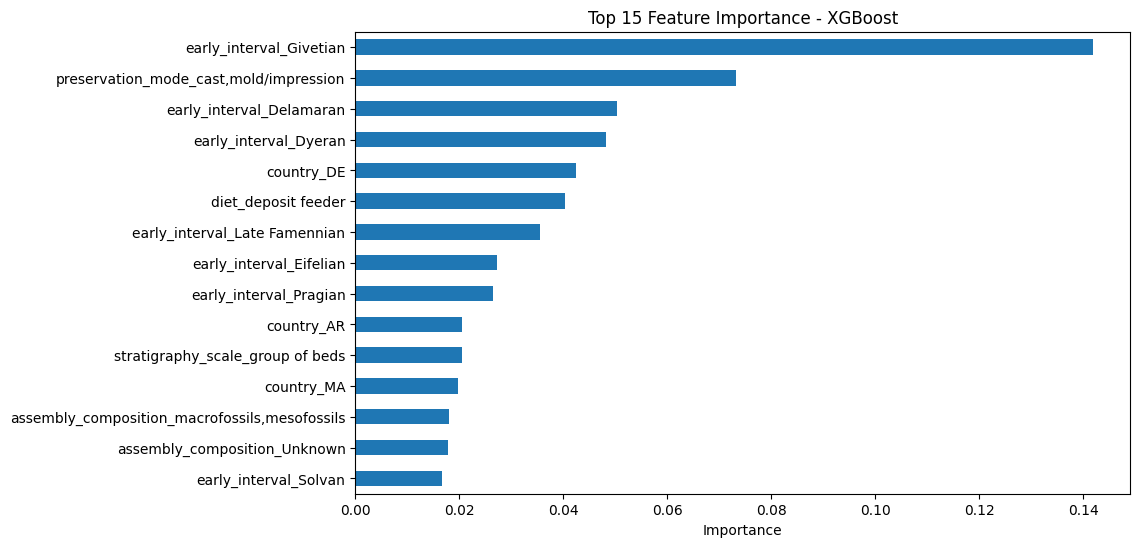

In [ ]:
# =========================================
# XGBOOST VISUALIZATION
# =========================================

import matplotlib.pyplot as plt
import pandas as pd

# 1) Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("XGBoost: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# 2) Residuals plot
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_xgb, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("XGBoost Residual Plot")
plt.show()

# 3) Feature importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_selected.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
xgb_importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importance - XGBoost")
plt.show()

# Extra Trees Regessor

In [ ]:
# =========================================
# EXTRA TREES REGRESSOR
# =========================================

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize model
et_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train
et_model.fit(X_train_selected, y_train)

# Predict
y_pred_et = et_model.predict(X_test_selected)

# Evaluate
et_mae = mean_absolute_error(y_test, y_pred_et)
et_rmse = np.sqrt(mean_squared_error(y_test, y_pred_et))
et_r2 = r2_score(y_test, y_pred_et)

print("Extra Trees")
print("MAE :", round(et_mae, 4))
print("RMSE:", round(et_rmse, 4))
print("R2  :", round(et_r2, 4))

Extra Trees
MAE : 2.3576
RMSE: 11.9344
R2  : 0.9402


In [ ]:
# =========================================
# EXTRA TREES COMPARISON TABLE
# =========================================

import pandas as pd

et_comparison_df = pd.DataFrame({
    "Model": [
        "Baseline - Linear Regression",
        "Random Forest",
        "XGBoost",
        "Extra Trees"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae,
        et_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        et_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2,
        xgb_r2,
        et_r2
    ]
})

print(et_comparison_df.sort_values(by="R2", ascending=False))

                          Model        MAE       RMSE        R2
1                 Random Forest   2.781772  11.334763  0.946055
3                   Extra Trees   2.357588  11.934440  0.940196
2                       XGBoost   6.218125  12.812375  0.931074
0  Baseline - Linear Regression  21.122419  31.791967  0.575616


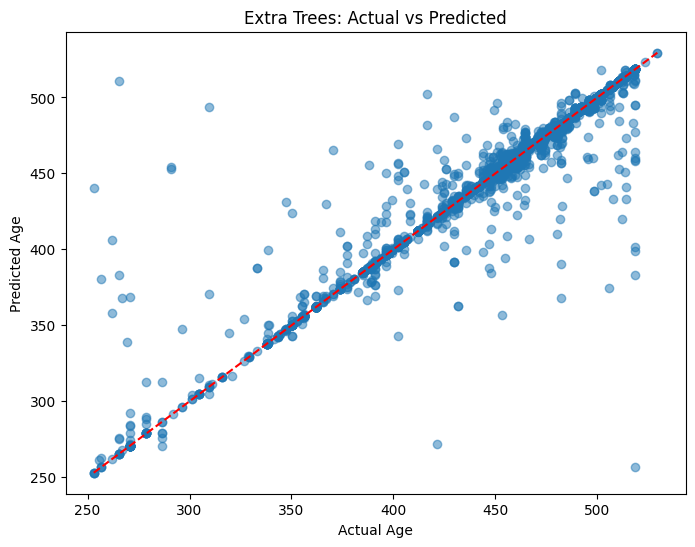

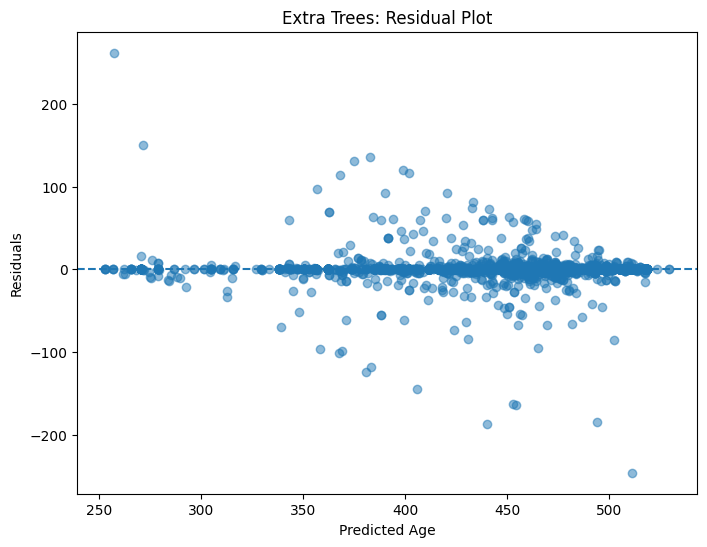

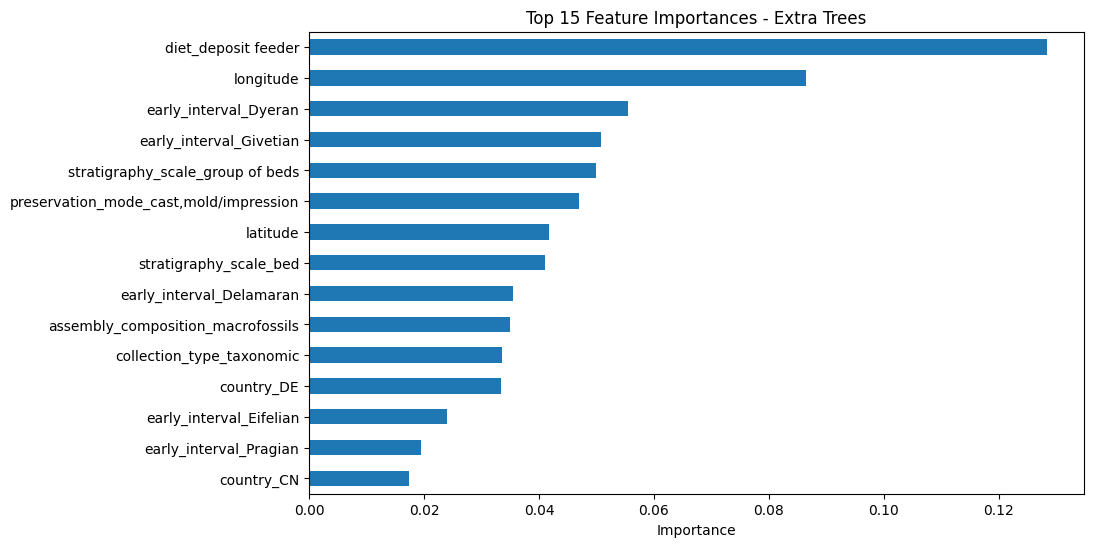

In [ ]:
# =========================================
# EXTRA TREES VISUALIZATION
# =========================================

import matplotlib.pyplot as plt
import pandas as pd

# 1) Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_et, alpha=0.5)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Extra Trees: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# 2) Residual plot
residuals_et = y_test - y_pred_et

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_et, residuals_et, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("Extra Trees: Residual Plot")
plt.show()

# 3) Feature importance
et_importance = pd.Series(
    et_model.feature_importances_,
    index=X_train_selected.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
et_importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Extra Trees")
plt.show()

# SVR

In [ ]:
# =========================================
# SVR REGRESSOR
# =========================================

from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize model
svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1,
    gamma="scale"
)

# Train
svr_model.fit(X_train_selected, y_train)

# Predict
y_pred_svr = svr_model.predict(X_test_selected)

# Evaluate
svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_r2 = r2_score(y_test, y_pred_svr)

print("SVR")
print("MAE :", round(svr_mae, 4))
print("RMSE:", round(svr_rmse, 4))
print("R2  :", round(svr_r2, 4))

SVR
MAE : 5.922
RMSE: 16.7701
R2  : 0.8819


In [ ]:
# =========================================
# SVR COMPARISON TABLE
# =========================================

import pandas as pd

svr_comparison_df = pd.DataFrame({
    "Model": [
        "Baseline - Linear Regression",
        "Random Forest",
        "XGBoost",
        "Extra Trees",
        "SVR"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae,
        et_mae,
        svr_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse,
        et_rmse,
        svr_rmse
    ],
    "R2": [
        baseline_r2,
        rf_r2,
        xgb_r2,
        et_r2,
        svr_r2
    ]
})

print(svr_comparison_df.sort_values(by="R2", ascending=False))

                          Model        MAE       RMSE        R2
1                 Random Forest   2.781772  11.334763  0.946055
3                   Extra Trees   2.357588  11.934440  0.940196
2                       XGBoost   6.218125  12.812375  0.931074
4                           SVR   5.922020  16.770120  0.881915
0  Baseline - Linear Regression  21.122419  31.791967  0.575616


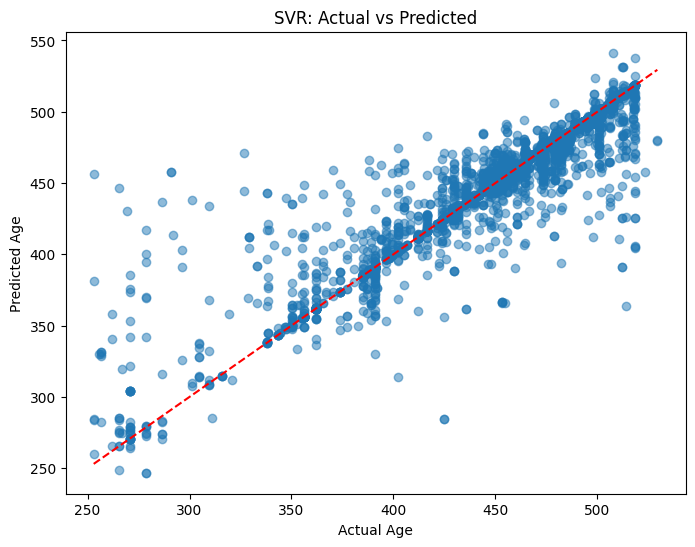

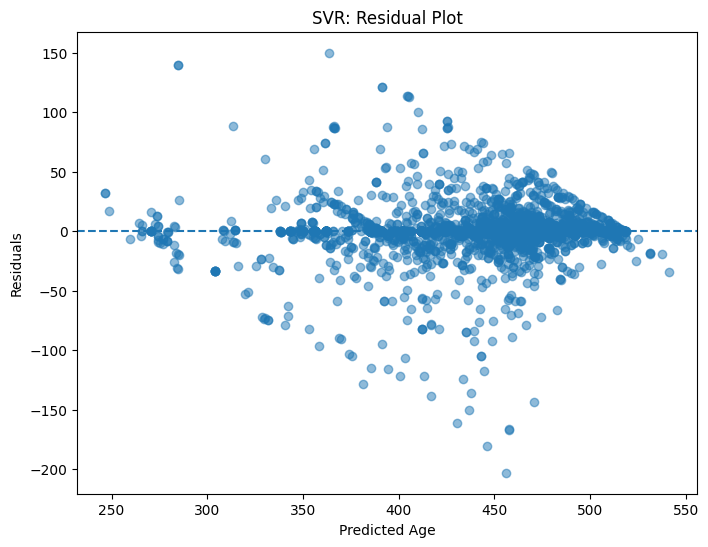

In [ ]:
# =========================================
# SVR VISUALIZATION
# =========================================

import matplotlib.pyplot as plt

# 1) Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.5)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("SVR: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

# 2) Residual plot
residuals_svr = y_test - y_pred_svr

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_svr, residuals_svr, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("SVR: Residual Plot")
plt.show()

# 3) Feature importance (Permutation)
from sklearn.inspection import permutation_importance
import pandas as pd

svr_importance = permutation_importance(
    svr_model,
    X_test_selected,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

svr_importance_series = pd.Series(
    svr_importance.importances_mean,
    index=X_train_selected.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
svr_importance_series.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - SVR (Permutation)")
plt.show()

# Fourth Model: Clustering

### Preprocessing

In [ ]:
# Check missing values
print(f"Missing values: {df1.isnull().sum().sum()}")
df1 = df1.dropna()

# Select numeric features
numeric_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID and age columns if present
numeric_cols = [col for col in numeric_cols if col.lower() not in ["id", "age"]]

X = df1[numeric_cols].copy()
print(f"Features for clustering: {X.shape[1]}")
print(X.describe())

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("✓ Features standardized")

Missing values: 55394
Features for clustering: 5
           genus_num  max_age_mya  min_age_mya   longitude    latitude
count     722.000000   722.000000   722.000000  722.000000  722.000000
mean    42422.930748   466.426593   458.263504   -4.016370   44.713424
std     69484.836372    34.185380    33.228155   66.162257   25.507429
min     19136.000000   266.900000   259.510000 -135.074005  -43.333332
25%     20053.000000   451.000000   449.500000  -64.233330   40.185673
50%     20851.000000   458.000000   453.000000    9.866667   52.089169
75%     21574.000000   486.850000   471.300000   15.200000   60.341667
max    491334.000000   530.700000   521.000000  152.266663   76.300003
✓ Features standardized


### Finding The Best K

In [ ]:
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, clusters))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, clusters))

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal clusters: {optimal_k}")
print(f"Silhouette Score: {silhouette_scores[optimal_k-2]:.4f}")

Optimal clusters: 10
Silhouette Score: 0.6171


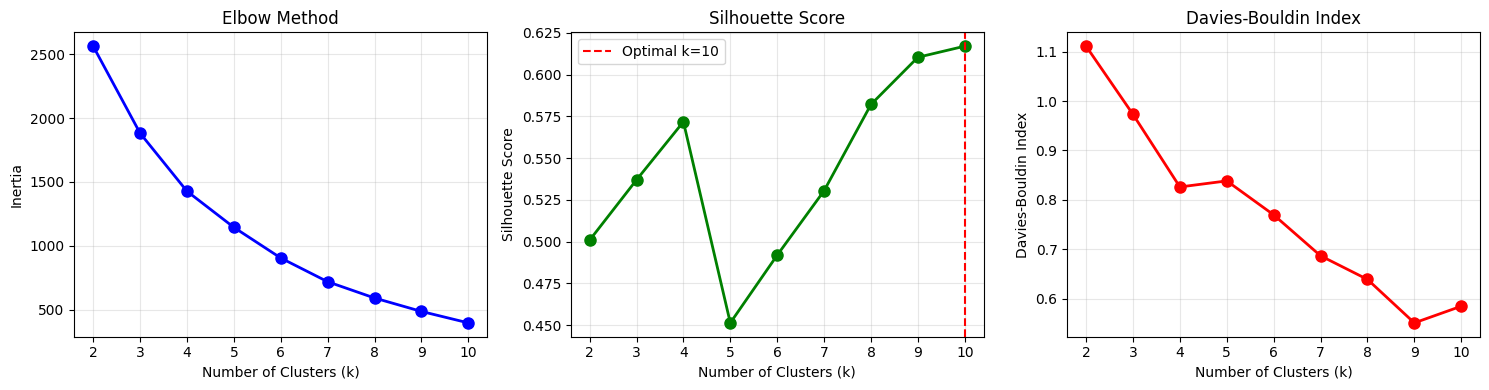

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, "go-", linewidth=2, markersize=8)
axes[1].axvline(optimal_k, color="red", linestyle="--", label=f"Optimal k={optimal_k}")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(K_range, davies_bouldin_scores, "ro-", linewidth=2, markersize=8)
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("Davies-Bouldin Index")
axes[2].set_title("Davies-Bouldin Index")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Applying K-Means

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print(f"Cluster distribution:")
unique, counts = np.unique(clusters, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} samples ({count/len(clusters)*100:.1f}%)")

Cluster distribution:
  Cluster 0: 172 samples (23.8%)
  Cluster 1: 128 samples (17.7%)
  Cluster 2: 36 samples (5.0%)
  Cluster 3: 7 samples (1.0%)
  Cluster 4: 32 samples (4.4%)
  Cluster 5: 43 samples (6.0%)
  Cluster 6: 237 samples (32.8%)
  Cluster 7: 23 samples (3.2%)
  Cluster 8: 20 samples (2.8%)
  Cluster 9: 24 samples (3.3%)


### Applying PCA for Visualization

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")

Variance explained: 67.3%
PC1: 45.1%
PC2: 22.2%


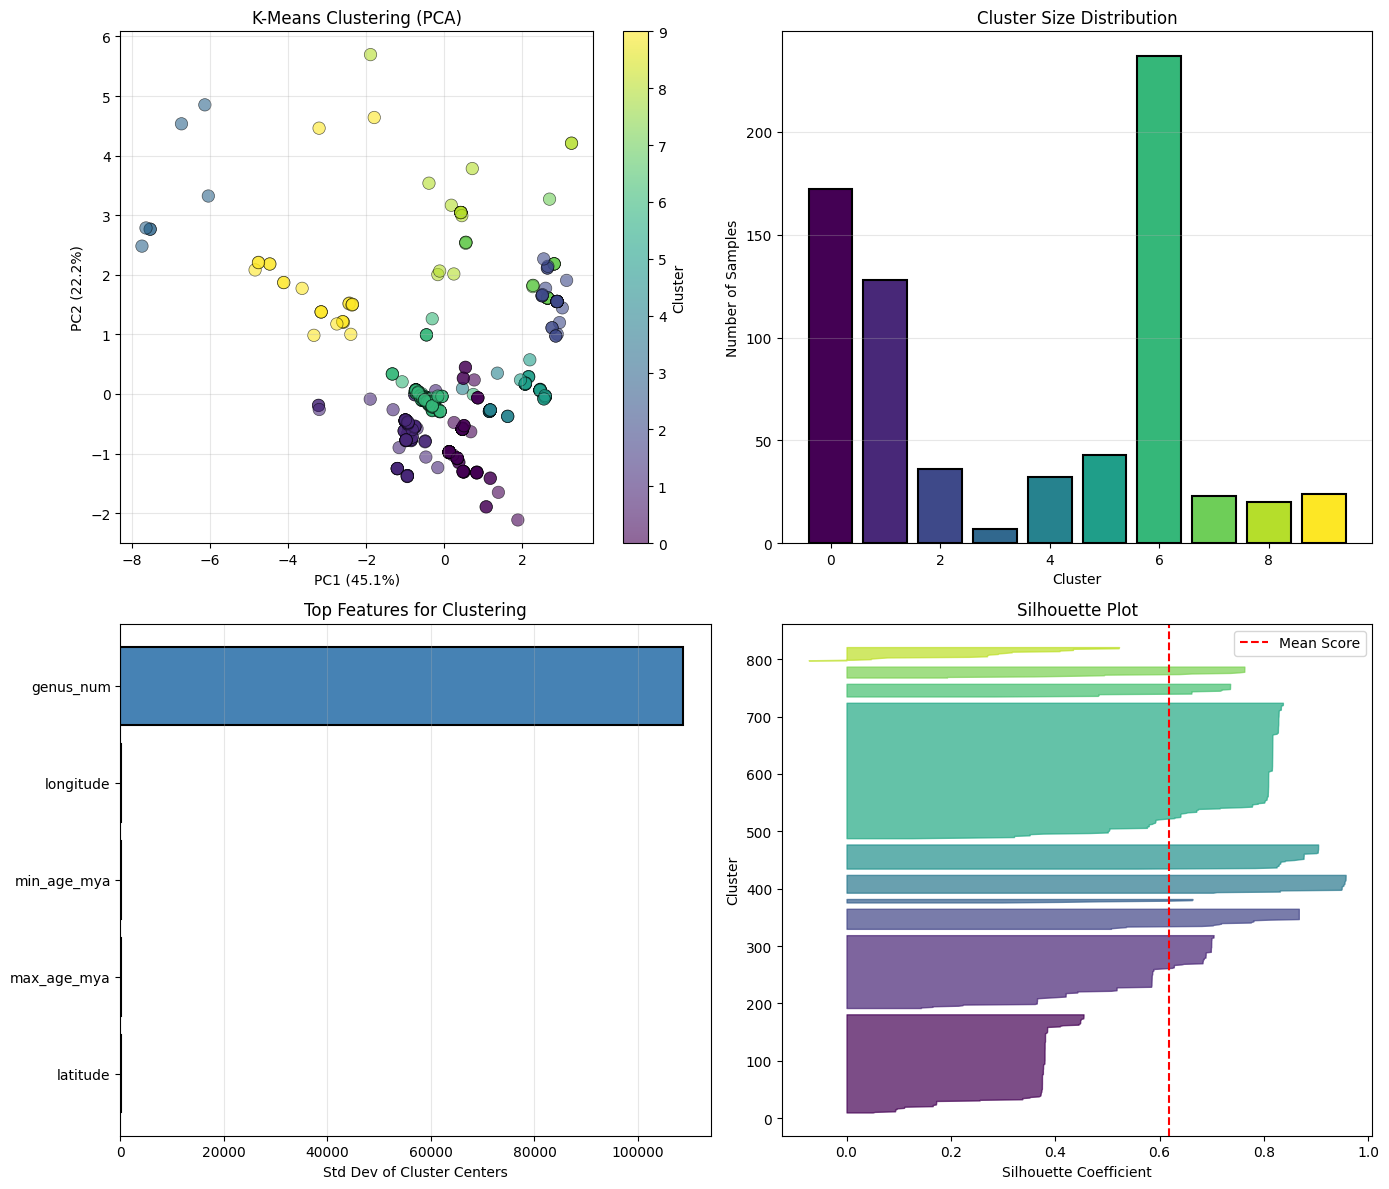

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# K-Means clusters
scatter = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", s=80, alpha=0.6, edgecolors="black", linewidth=0.5)
axes[0, 0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0, 0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0, 0].set_title("K-Means Clustering (PCA)")
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 0], label="Cluster")

# Cluster sizes
cluster_counts = pd.Series(clusters).value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))
axes[0, 1].bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor="black", linewidth=1.5)
axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Number of Samples")
axes[0, 1].set_title("Cluster Size Distribution")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# Feature importance
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
feature_importance = np.std(cluster_centers_original, axis=0)
top_features_idx = np.argsort(feature_importance)[-8:]
feature_names = X.columns[top_features_idx]
feature_vals = feature_importance[top_features_idx]

axes[1, 0].barh(range(len(feature_names)), feature_vals, color="steelblue", edgecolor="black", linewidth=1.5)
axes[1, 0].set_yticks(range(len(feature_names)))
axes[1, 0].set_yticklabels(feature_names)
axes[1, 0].set_xlabel("Std Dev of Cluster Centers")
axes[1, 0].set_title("Top Features for Clustering")
axes[1, 0].grid(True, alpha=0.3, axis="x")

# Silhouette analysis
from sklearn.metrics import silhouette_samples
silhouette_vals = silhouette_samples(X_scaled, clusters)
y_lower = 10
for i in range(optimal_k):
    cluster_silhouette_vals = silhouette_vals[clusters == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    color = plt.cm.viridis(float(i) / optimal_k)
    axes[1, 1].fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, facecolor=color, edgecolor=color, alpha=0.7)
    y_lower = y_upper + 10
axes[1, 1].axvline(x=silhouette_vals.mean(), color="red", linestyle="--", label="Mean Score")
axes[1, 1].set_xlabel("Silhouette Coefficient")
axes[1, 1].set_ylabel("Cluster")
axes[1, 1].set_title("Silhouette Plot")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Cluster Analysis

In [ ]:
X_with_clusters = X.copy()
X_with_clusters["Cluster"] = clusters

for cluster_id in range(optimal_k):
    cluster_data = X_with_clusters[X_with_clusters["Cluster"] == cluster_id].drop("Cluster", axis=1)
    print(f"\n=== CLUSTER {cluster_id} (n={len(cluster_data)}) ===")
    print(cluster_data.describe().loc[["mean", "std"]].round(3))


=== CLUSTER 0 (n=172) ===
      genus_num  max_age_mya  min_age_mya  longitude  latitude
mean  27921.378      487.279      474.863     -28.95    53.288
std   31886.634        6.392        8.246      40.22     7.787

=== CLUSTER 1 (n=128) ===
      genus_num  max_age_mya  min_age_mya  longitude  latitude
mean  22860.398      452.710      446.381    -83.904    49.114
std   12605.461        9.547       10.149     18.988     8.976

=== CLUSTER 2 (n=36) ===
       genus_num  max_age_mya  min_age_mya  longitude  latitude
mean  182183.139      512.972      502.881    108.596    28.434
std    27456.099        5.771        3.725      2.145     2.805

=== CLUSTER 3 (n=7) ===
      genus_num  max_age_mya  min_age_mya  longitude  latitude
mean  21168.857      276.829      266.606    -25.576    30.657
std      87.423       10.126       10.601    104.542    16.743

=== CLUSTER 4 (n=32) ===
      genus_num  max_age_mya  min_age_mya  longitude  latitude
mean  22590.031      490.947      477.812    -6

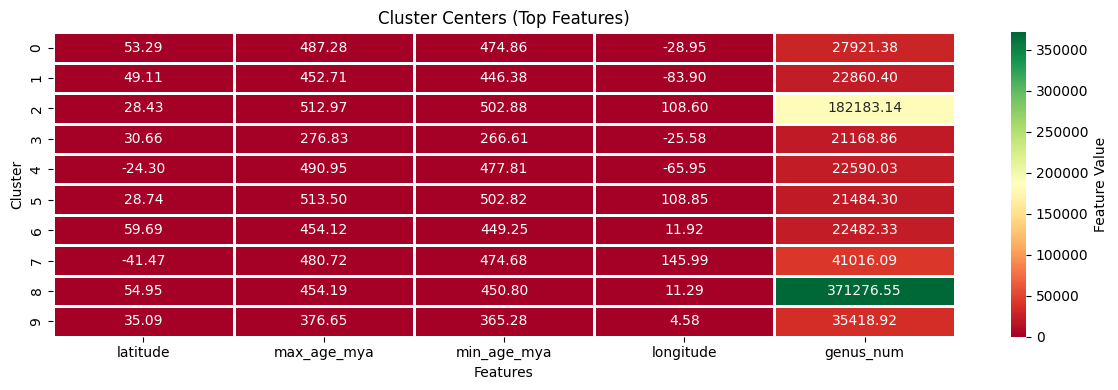

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
cluster_centers_df = pd.DataFrame(cluster_centers_original, columns=X.columns)
top_features_idx = np.argsort(feature_importance)[-10:]
cluster_centers_heatmap = cluster_centers_df.iloc[:, top_features_idx]

sns.heatmap(cluster_centers_heatmap, annot=True, fmt=".2f", cmap="RdYlGn", cbar_kws={"label": "Feature Value"}, linewidths=1, ax=ax)
ax.set_xlabel("Features")
ax.set_ylabel("Cluster")
ax.set_title("Cluster Centers (Top Features)")
plt.tight_layout()
plt.show()

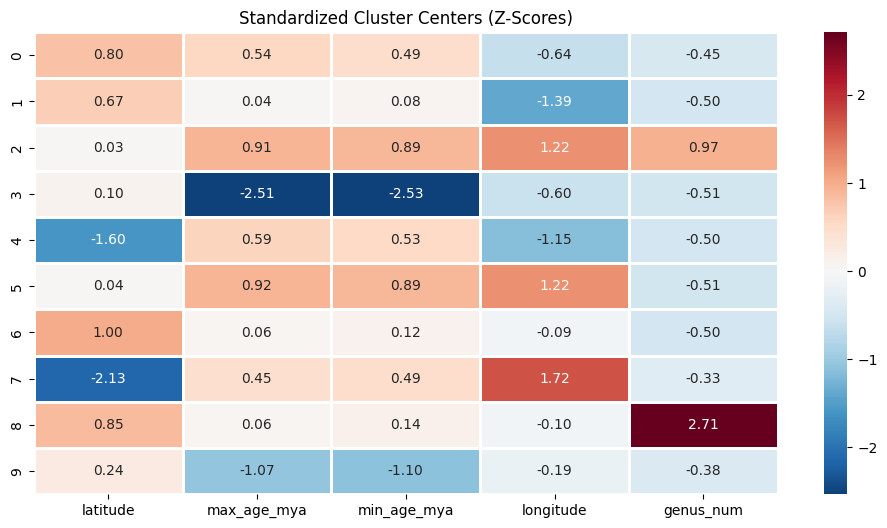

In [ ]:
# Scaling cluster centers for better visualization
scaler = StandardScaler()
cluster_centers_scaled = scaler.fit_transform(cluster_centers_original)

cluster_centers_df = pd.DataFrame(cluster_centers_scaled, columns=X.columns)
top_features_idx = np.argsort(feature_importance)[-10:]
cluster_centers_heatmap = cluster_centers_df.iloc[:, top_features_idx]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    cluster_centers_heatmap,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=1,
    ax=ax
)

ax.set_title("Standardized Cluster Centers (Z-Scores)")
plt.show()

### Geological & Biogeographic Cluster Analysis


#### The Cambrian Giants (Early Diversity)
**Cluster 2 & 5:** These are the oldest and most diverse clusters. Located around longitude 108° and latitude 28°, these represent the South China Plate. Cluster 2 has a massive genus_num mean (~182k), suggesting it captures a "Lagerstätte" (a site with extraordinary fossil richness like the Chengjiang Biota).

**Cluster 4:** This group (~490 mya) represents the Gondwanan province, specifically the region that is now South America (Long -65, Lat -24).

#### The Ordovician Peak (Global Expansion)
**Cluster 0 & 6:** These represent the Northern Hemisphere dominance, likely covering Laurentia (North America) and Baltica (Europe/Scandinavia). Cluster 6 is the largest group ($n=237$), indicating that the dataset is heavily weighted toward the Middle Ordovician period (~454 mya).

**Cluster 7:** A very specific isolated group in the Southern Hemisphere (Long 145, Lat -41), representing Australia/Tasmania. It shows a high standard deviation in age, suggesting it captures a long-term evolutionary sequence in a single stable environment.

**Cluster 1:** This is a tight North American grouping (Long -83, Lat 49), likely focusing on the Great Lakes/Appalachian regions during the Late Ordovician.

#### The Final Survivors & Deviants
**Cluster 3:** This is the Permian "Extinction" group. With the youngest age (~276 mya) and a very small sample size ($n=7$), it represents the final, rare trilobite lineages before they went extinct forever.

**Cluster 8 & 9:** These are the Taxonomic Outliers. Cluster 8 has an extremely high genus_num (~371k), which likely indicates either a data-entry artifact or a specific genus that was incredibly widespread and successful across Europe.